# Forecasting EDA
**Objective:** Classify revenue patterns into Trend, Seasonality, Event Effects, Store Hierarchy Effects, and Noise to guide feature engineering and model selection.

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats
from statsmodels.tsa.stattools import acf, pacf
from statsmodels.tsa.seasonal import seasonal_decompose

# ── Style ──────────────────────────────────────────────────────────────────────
plt.rcParams.update({
    'figure.dpi': 120,
    'figure.facecolor': 'white',
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'font.size': 11,
})
PALETTE = sns.color_palette('tab10')

print('Libraries loaded successfully.')

Libraries loaded successfully.


---
## 0. Load & Prepare Data

In [3]:
# ── Load ───────────────────────────────────────────────────────────────────────
train = pd.read_csv('data/train.csv', parse_dates=['date'])
events = pd.read_csv('data/calendar_events.csv', parse_dates=['date'])

# ── Feature engineering ────────────────────────────────────────────────────────
train = train.sort_values(['store_id', 'date']).reset_index(drop=True)
train['dow']     = train['date'].dt.dayofweek          # 0=Mon … 6=Sun
train['dow_name']= train['date'].dt.day_name()
train['month']   = train['date'].dt.month
train['month_name'] = train['date'].dt.month_name()
train['quarter'] = train['date'].dt.quarter
train['year']    = train['date'].dt.year
train['week']    = train['date'].dt.isocalendar().week.astype(int)
train['day_of_month'] = train['date'].dt.day

# ── Derive state from store name ───────────────────────────────────────────────
def get_state(name):
    if 'California' in str(name): return 'California'
    if 'Texas'      in str(name): return 'Texas'
    if 'Wisconsin'  in str(name): return 'Wisconsin'
    return 'All'

train['state'] = train['store_name'].apply(get_state)

# ── Convenience subsets ────────────────────────────────────────────────────────
global_df  = train[train['store_id'] == 0].copy()
stores_df  = train[train['store_id'] != 0].copy()
store_ids  = sorted(stores_df['store_id'].unique())
store_meta = stores_df[['store_id','store_name','state']].drop_duplicates().set_index('store_id')

print(f"Train rows        : {len(train):,}")
print(f"Date range        : {train['date'].min().date()} → {train['date'].max().date()}")
print(f"Stores (excl. 0)  : {len(store_ids)}")
print(f"States            : {train['state'].unique().tolist()}")
print(f"Calendar events   : {len(events):,} rows | {events['event'].nunique()} unique events")
print()
print(store_meta.to_string())

Train rows        : 18,766
Date range        : 2011-01-29 → 2015-09-30
Stores (excl. 0)  : 10
States            : ['All', 'California', 'Texas', 'Wisconsin']
Calendar events   : 162 rows | 34 unique events

                           store_name       state
store_id                                         
1           California – Sunset Plaza  California
2             California – Ocean View  California
3           California – Golden Hills  California
4         California – Redwood Center  California
5              Texas – Lone Star Mall       Texas
6            Texas – Riverwalk Market       Texas
7               Texas – Alamo Heights       Texas
8             Wisconsin – Maple Grove   Wisconsin
9          Wisconsin – Lakeview Plaza   Wisconsin
10        Wisconsin – Badger Crossing   Wisconsin


---
## 1. Data Sanity & Structure
### 1.1 Time Coverage

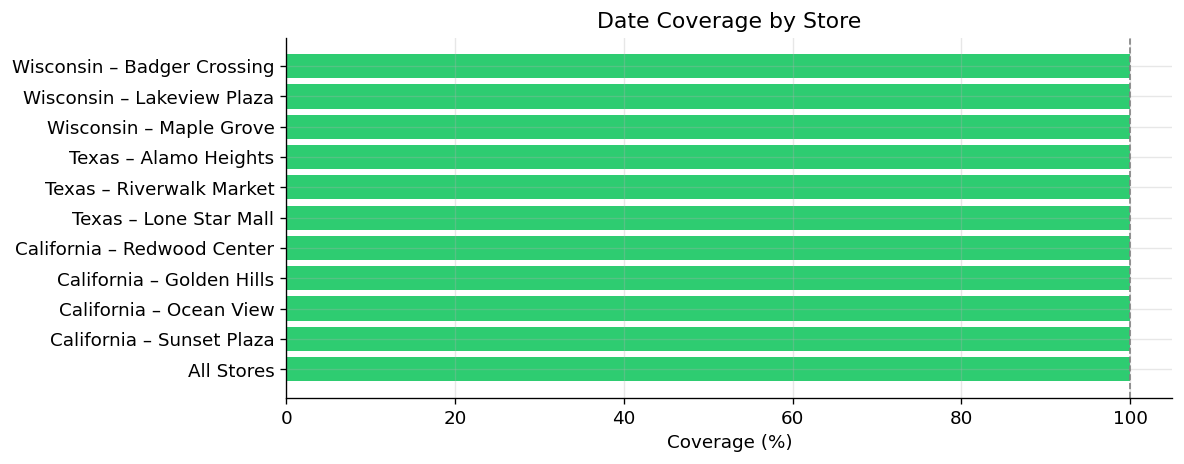

                 store_name  rows  expected  missing_days  coverage_%
                 All Stores  1706      1706             0       100.0
  California – Sunset Plaza  1706      1706             0       100.0
    California – Ocean View  1706      1706             0       100.0
  California – Golden Hills  1706      1706             0       100.0
California – Redwood Center  1706      1706             0       100.0
     Texas – Lone Star Mall  1706      1706             0       100.0
   Texas – Riverwalk Market  1706      1706             0       100.0
      Texas – Alamo Heights  1706      1706             0       100.0
    Wisconsin – Maple Grove  1706      1706             0       100.0
 Wisconsin – Lakeview Plaza  1706      1706             0       100.0
Wisconsin – Badger Crossing  1706      1706             0       100.0

► Total missing-date entries across all series: 0
► VERDICT: Timeline is complete and continuous. No missing-date imputation required.


In [4]:
full_range = pd.date_range(global_df['date'].min(), global_df['date'].max(), freq='D')

missing_summary = []
for sid in [0] + store_ids:
    sub = train[train['store_id'] == sid]
    covered = set(sub['date'])
    missing = [d for d in full_range if d not in covered]
    missing_summary.append({'store_id': sid,
                            'store_name': sub['store_name'].iloc[0],
                            'rows': len(sub),
                            'expected': len(full_range),
                            'missing_days': len(missing),
                            'coverage_%': round(100 * len(sub) / len(full_range), 2)})

coverage_df = pd.DataFrame(missing_summary)

fig, ax = plt.subplots(figsize=(10, 4))
colors = ['#e74c3c' if x > 0 else '#2ecc71' for x in coverage_df['missing_days']]
ax.barh(coverage_df['store_name'], coverage_df['coverage_%'], color=colors)
ax.axvline(100, ls='--', color='grey', lw=1)
ax.set_xlabel('Coverage (%)')
ax.set_title('Date Coverage by Store')
plt.tight_layout()
plt.show()

print(coverage_df[['store_name','rows','expected','missing_days','coverage_%']].to_string(index=False))
total_missing = coverage_df['missing_days'].sum()
print(f"\n► Total missing-date entries across all series: {total_missing}")
if total_missing == 0:
    print("► VERDICT: Timeline is complete and continuous. No missing-date imputation required.")
else:
    print("► VERDICT: Gaps detected — forward-fill or interpolation should be applied before modelling.")

### 1.2 Store Coverage

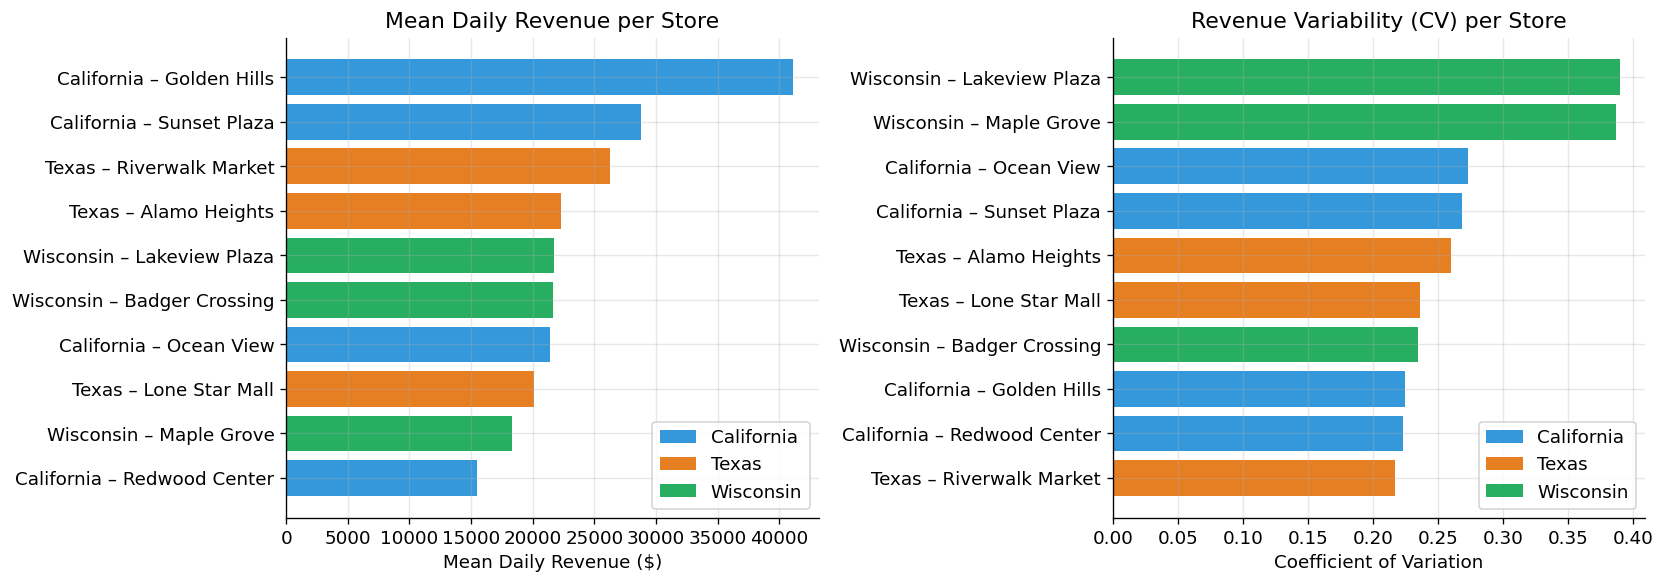

                 store_name      state  days  mean_rev  std_rev   cv   total_rev
  California – Golden Hills California  1706  41134.34  9239.93 0.22 70175190.62
  California – Sunset Plaza California  1706  28756.90  7716.51 0.27 49059268.03
   Texas – Riverwalk Market      Texas  1706  26304.04  5710.32 0.22 44874692.16
      Texas – Alamo Heights      Texas  1706  22268.39  5791.86 0.26 37989881.76
 Wisconsin – Lakeview Plaza  Wisconsin  1706  21709.92  8459.09 0.39 37037116.58
Wisconsin – Badger Crossing  Wisconsin  1706  21650.29  5072.44 0.23 36935394.33
    California – Ocean View California  1706  21393.61  5838.00 0.27 36497502.03
     Texas – Lone Star Mall      Texas  1706  20081.25  4736.54 0.24 34258610.14
    Wisconsin – Maple Grove  Wisconsin  1706  18289.56  7070.12 0.39 31201982.01
California – Redwood Center California  1706  15469.16  3444.79 0.22 26390378.44

► Most volatile store : Wisconsin – Lakeview Plaza
► Most stable store   : Texas – Riverwalk Market
► VERDIC

In [5]:
store_stats = stores_df.groupby(['store_id','store_name','state'])['revenue'].agg(
    days='count', mean='mean', std='std', total='sum'
).reset_index()
store_stats['cv'] = store_stats['std'] / store_stats['mean']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Mean revenue by store
order = store_stats.sort_values('mean', ascending=True)
colors_state = {'California': '#3498db', 'Texas': '#e67e22', 'Wisconsin': '#27ae60'}
bar_colors = [colors_state[s] for s in order['state']]
axes[0].barh(order['store_name'], order['mean'], color=bar_colors)
axes[0].set_xlabel('Mean Daily Revenue ($)')
axes[0].set_title('Mean Daily Revenue per Store')
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=v, label=k) for k, v in colors_state.items()]
axes[0].legend(handles=legend_elements, loc='lower right')

# CV by store
order2 = store_stats.sort_values('cv', ascending=True)
axes[1].barh(order2['store_name'], order2['cv'],
             color=[colors_state[s] for s in order2['state']])
axes[1].set_xlabel('Coefficient of Variation')
axes[1].set_title('Revenue Variability (CV) per Store')
axes[1].legend(handles=legend_elements, loc='lower right')

plt.tight_layout()
plt.show()

print(store_stats[['store_name','state','days','mean','std','cv','total']]
      .sort_values('mean', ascending=False)
      .rename(columns={'mean':'mean_rev','std':'std_rev','total':'total_rev'})
      .to_string(index=False, float_format='%.2f'))
print()
max_cv = store_stats.loc[store_stats['cv'].idxmax(), 'store_name']
min_cv = store_stats.loc[store_stats['cv'].idxmin(), 'store_name']
print(f"► Most volatile store : {max_cv}")
print(f"► Most stable store   : {min_cv}")
print("► VERDICT: Revenue scale differs meaningfully across stores; log-transform or store-level normalisation recommended.")

### 1.3 Revenue Distribution

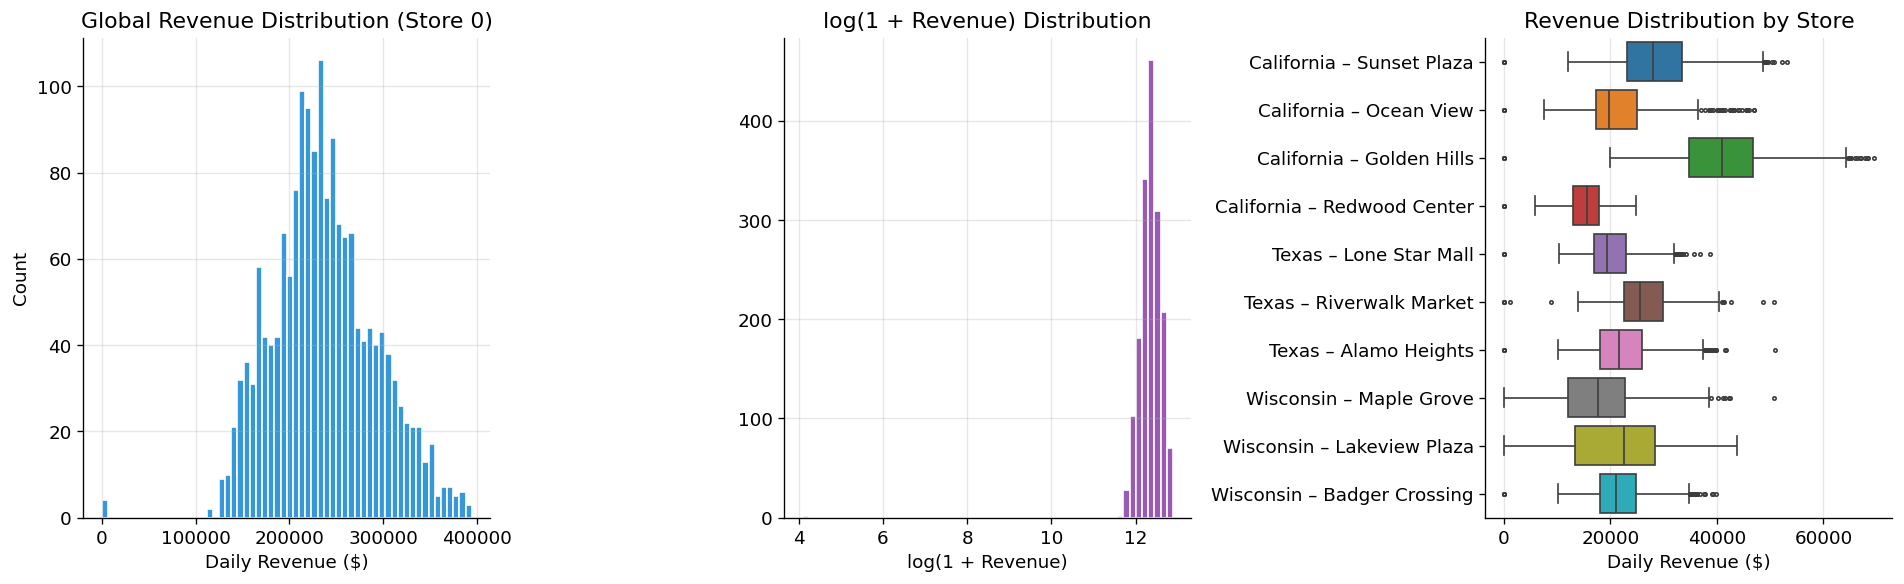

Global revenue — mean : $237,057  |  median : $232,949
Global revenue — std  : $54,634  |  skewness : 0.152
Zero-revenue days     : 0.0%
99th-percentile       : $369,280  |  days above that threshold: 18

► VERDICT: Scale heterogeneity across stores confirms per-store normalisation is needed.


In [7]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Global histogram
axes[0].hist(global_df['revenue'], bins=60, color='#3498db', edgecolor='white', lw=0.5)
axes[0].set_title('Global Revenue Distribution (Store 0)')
axes[0].set_xlabel('Daily Revenue ($)')
axes[0].set_ylabel('Count')

# Log-transformed
axes[1].hist(np.log1p(global_df['revenue']), bins=60, color='#9b59b6', edgecolor='white', lw=0.5)
axes[1].set_title('log(1 + Revenue) Distribution')
axes[1].set_xlabel('log(1 + Revenue)')

# Per-store box
plot_data = stores_df.sort_values('store_id')
store_order = [store_meta.loc[s,'store_name'] for s in store_ids]
sns.boxplot(data=plot_data, x='revenue', y='store_name', order=store_order,
            palette='tab10', ax=axes[2], fliersize=2)
axes[2].set_title('Revenue Distribution by Store')
axes[2].set_xlabel('Daily Revenue ($)')
axes[2].set_ylabel('')

plt.tight_layout()
plt.show()

zero_pct = 100 * (global_df['revenue'] == 0).mean()
skewness  = global_df['revenue'].skew()
q99       = global_df['revenue'].quantile(0.99)
outliers  = (global_df['revenue'] > q99).sum()

print(f"Global revenue — mean : ${global_df['revenue'].mean():,.0f}  |  median : ${global_df['revenue'].median():,.0f}")
print(f"Global revenue — std  : ${global_df['revenue'].std():,.0f}  |  skewness : {skewness:.3f}")
print(f"Zero-revenue days     : {zero_pct:.1f}%")
print(f"99th-percentile       : ${q99:,.0f}  |  days above that threshold: {outliers}")
print()
if skewness > 0.5:
    print("► Revenue is right-skewed — log or square-root transformation is advisable for most models.")
if zero_pct > 0:
    print(f"► {zero_pct:.1f}% zero-revenue days detected — consider a two-stage model.")
print("► VERDICT: Scale heterogeneity across stores confirms per-store normalisation is needed.")

---
## 2. Global Temporal Patterns
### 2.1 Trend Analysis

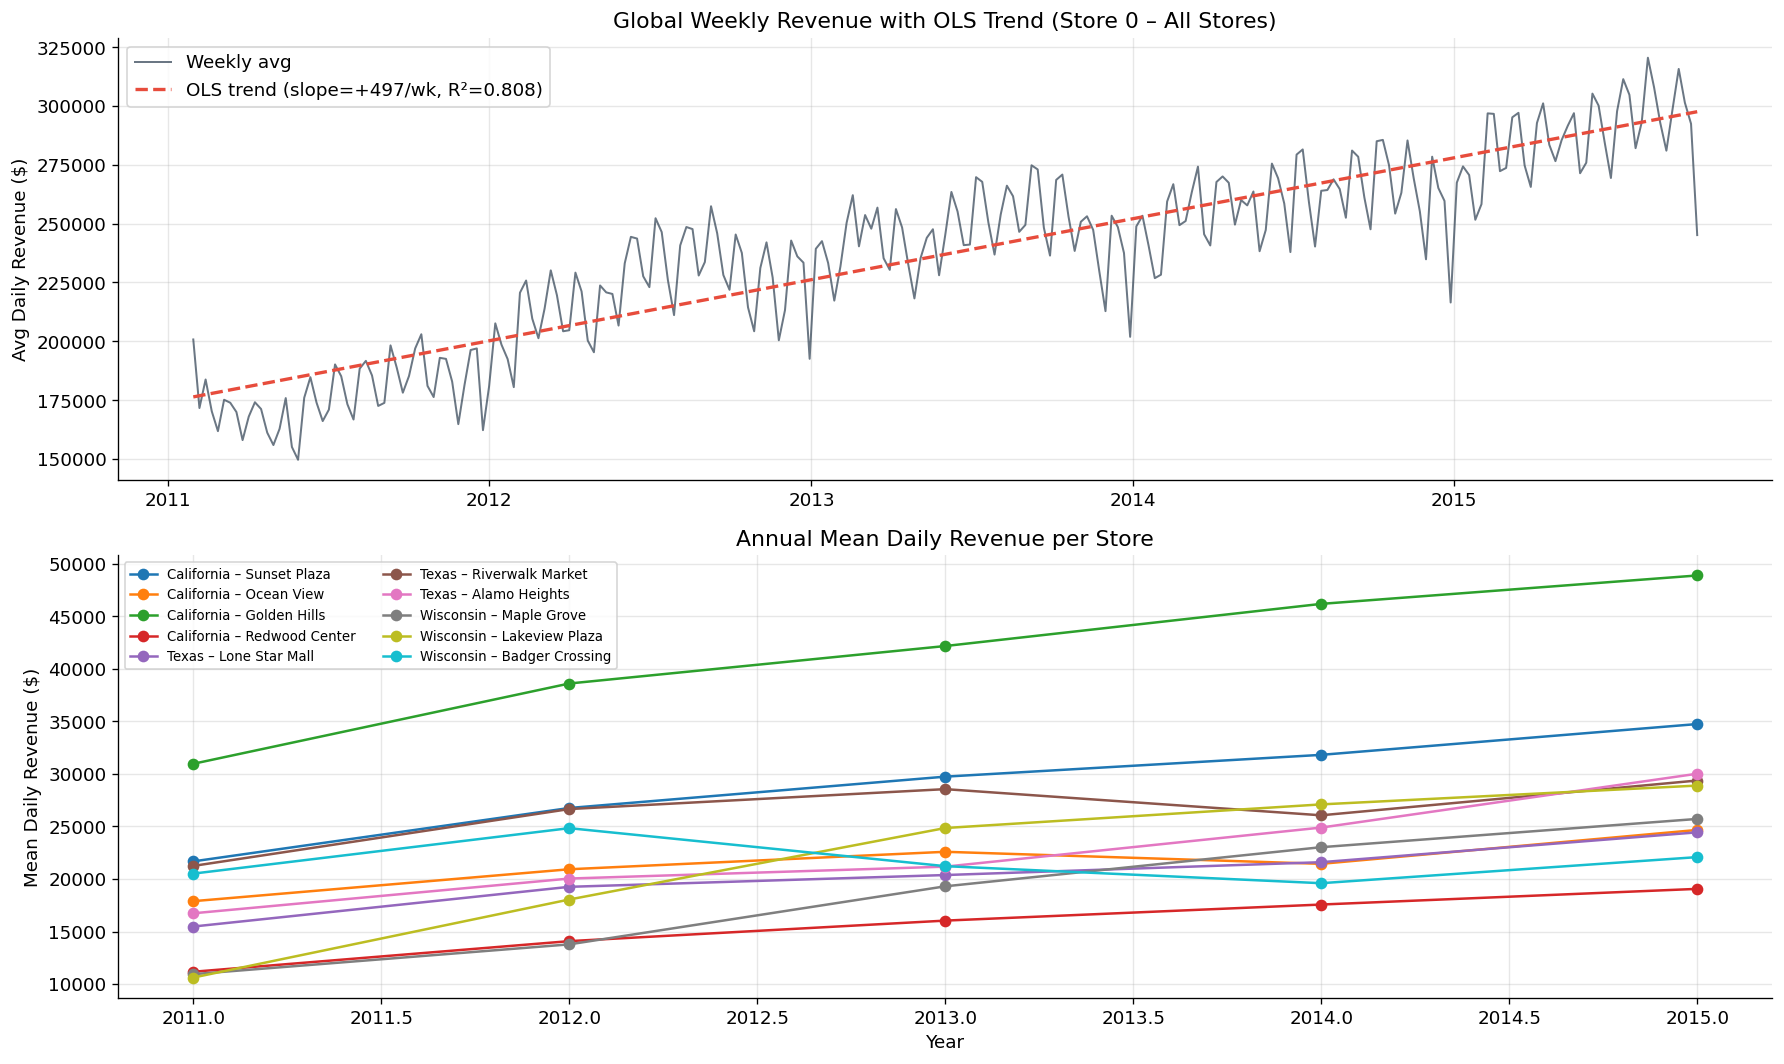

Per-store OLS slope (weekly revenue change):
Store                                 Slope ($/wk)       R²    Direction
------------------------------------------------------------------------
California – Sunset Plaza                   +60.63    0.791    ▲ Growing
California – Ocean View                     +27.47    0.367    ▲ Growing
California – Golden Hills                   +85.53    0.768    ▲ Growing
California – Redwood Center                 +37.94    0.892    ▲ Growing
Texas – Lone Star Mall                      +38.38    0.737    ▲ Growing
Texas – Riverwalk Market                    +29.22    0.394    ▲ Growing
Texas – Alamo Heights                       +59.18    0.816    ▲ Growing
Wisconsin – Maple Grove                     +75.65    0.894    ▲ Growing
Wisconsin – Lakeview Plaza                  +90.64    0.701    ▲ Growing
Wisconsin – Badger Crossing                  -7.80    0.030  ▼ Declining

Global trend slope : +496.82 $/week  |  R² = 0.808
► VERDICT: Global trend is 

In [8]:
fig, axes = plt.subplots(2, 1, figsize=(15, 9), sharex=False)

# ── Global trend ───────────────────────────────────────────────────────────────
weekly_global = global_df.set_index('date')['revenue'].resample('W').mean()
axes[0].plot(weekly_global.index, weekly_global.values, color='#2c3e50', lw=1.2, alpha=0.7, label='Weekly avg')
# OLS trend line
x_num = np.arange(len(weekly_global))
slope, intercept, r, p, _ = stats.linregress(x_num, weekly_global.values)
axes[0].plot(weekly_global.index, intercept + slope * x_num,
             color='#e74c3c', lw=2, ls='--', label=f'OLS trend (slope={slope:+.0f}/wk, R²={r**2:.3f})')
axes[0].set_title('Global Weekly Revenue with OLS Trend (Store 0 – All Stores)')
axes[0].set_ylabel('Avg Daily Revenue ($)')
axes[0].legend()

# ── Per-store annual trend ─────────────────────────────────────────────────────
annual = stores_df.groupby(['store_id','store_name','year'])['revenue'].mean().reset_index()
for i, sid in enumerate(store_ids):
    sub = annual[annual['store_id'] == sid]
    axes[1].plot(sub['year'], sub['revenue'], marker='o', label=store_meta.loc[sid,'store_name'],
                 color=PALETTE[i])
axes[1].set_title('Annual Mean Daily Revenue per Store')
axes[1].set_ylabel('Mean Daily Revenue ($)')
axes[1].set_xlabel('Year')
axes[1].legend(fontsize=8, ncol=2)

plt.tight_layout()
plt.show()

# Per-store slope
print("Per-store OLS slope (weekly revenue change):")
print(f"{'Store':<35} {'Slope ($/wk)':>14} {'R²':>8} {'Direction':>12}")
print('-' * 72)
for sid in store_ids:
    sub = stores_df[stores_df['store_id'] == sid].set_index('date')['revenue'].resample('W').mean().dropna()
    x = np.arange(len(sub))
    sl, ic, r_, p_, _ = stats.linregress(x, sub.values)
    direction = '▲ Growing' if sl > 0 else '▼ Declining'
    print(f"{store_meta.loc[sid,'store_name']:<35} {sl:>+14.2f} {r_**2:>8.3f} {direction:>12}")

print(f"\nGlobal trend slope : {slope:+.2f} $/week  |  R² = {r**2:.3f}")
trend_direction = 'upward' if slope > 0 else 'downward'
print(f"► VERDICT: Global trend is {trend_direction}. Per-store trends vary, suggesting BOTH global and store-specific trend components are needed.")

### 2.2 Seasonality Analysis — Weekly

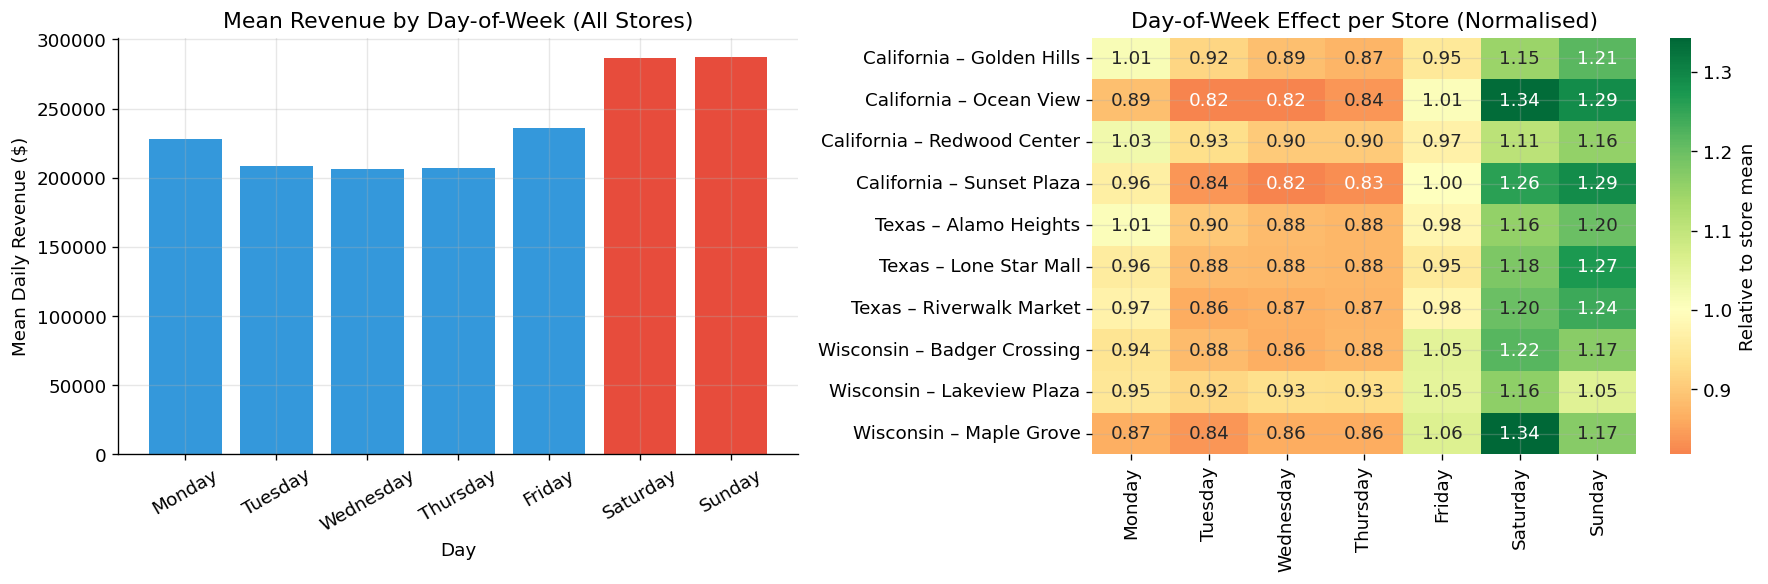

Global weekday avg : $217,220  |  Weekend avg : $286,587
Peak day : Sunday ($286,956)
Trough day : Wednesday ($206,402)
Weekend/weekday ratio : 1.319
► Weekly seasonality is STRONG — day-of-week features are essential.


In [9]:
dow_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Global day-of-week
dow_global = global_df.groupby('dow_name')['revenue'].mean().reindex(dow_order)
bar_colors = ['#3498db' if d not in ['Saturday','Sunday'] else '#e74c3c' for d in dow_order]
axes[0].bar(dow_order, dow_global.values, color=bar_colors)
axes[0].set_title('Mean Revenue by Day-of-Week (All Stores)')
axes[0].set_ylabel('Mean Daily Revenue ($)')
axes[0].set_xlabel('Day')
axes[0].tick_params(axis='x', rotation=30)

# Per-store heatmap
dow_store = stores_df.groupby(['store_name','dow_name'])['revenue'].mean().unstack()[dow_order]
dow_store_norm = dow_store.div(dow_store.mean(axis=1), axis=0)  # relative to each store mean
sns.heatmap(dow_store_norm, annot=True, fmt='.2f', cmap='RdYlGn', center=1.0,
            ax=axes[1], cbar_kws={'label': 'Relative to store mean'})
axes[1].set_title('Day-of-Week Effect per Store (Normalised)')
axes[1].set_xlabel('')
axes[1].set_ylabel('')

plt.tight_layout()
plt.show()

wkd = dow_global[['Monday','Tuesday','Wednesday','Thursday','Friday']].mean()
wke = dow_global[['Saturday','Sunday']].mean()
peak_day = dow_global.idxmax()
low_day  = dow_global.idxmin()
print(f"Global weekday avg : ${wkd:,.0f}  |  Weekend avg : ${wke:,.0f}")
print(f"Peak day : {peak_day} (${dow_global[peak_day]:,.0f})")
print(f"Trough day : {low_day} (${dow_global[low_day]:,.0f})")
print(f"Weekend/weekday ratio : {wke/wkd:.3f}")
if abs(wke/wkd - 1) > 0.05:
    print("► Weekly seasonality is STRONG — day-of-week features are essential.")
else:
    print("► Weekly seasonality is weak — day-of-week effect is minimal.")

### 2.2 Seasonality Analysis — Monthly & Quarterly

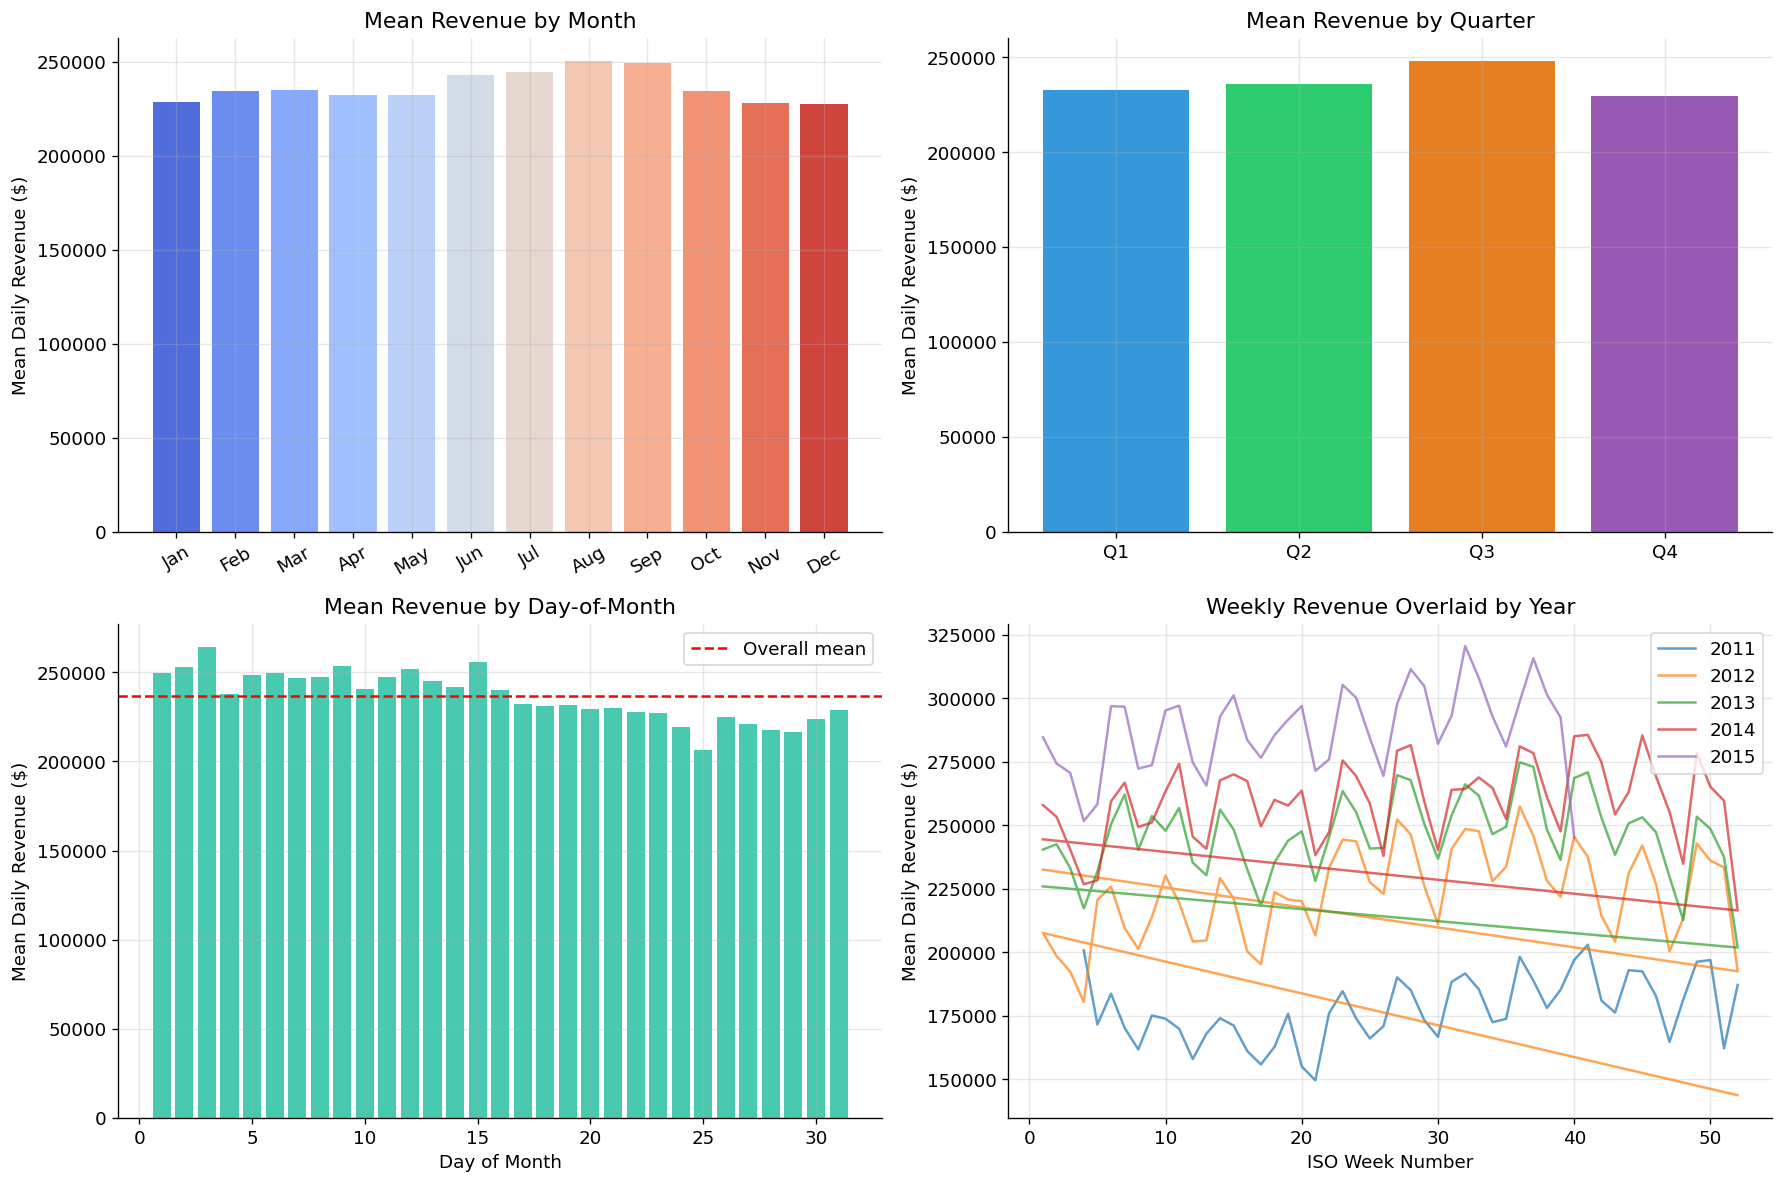

Peak month  : August ($250,262)
Trough month: December ($227,308)
Max monthly index / min monthly index : 1.101
Q spread (max Q / min Q) : 1.079
Beginning-of-month avg : $250,016  |  Mid-month avg : $239,640  |  End-of-month avg : $219,369

► VERDICT:
  Monthly seasonality : STRONG
  Quarterly effect    : STRONG


In [10]:
month_names = ['January','February','March','April','May','June',
               'July','August','September','October','November','December']

fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Monthly
monthly = global_df.groupby('month_name')['revenue'].mean().reindex(month_names)
axes[0,0].bar(range(1,13), monthly.values, color=sns.color_palette('coolwarm', 12))
axes[0,0].set_xticks(range(1,13))
axes[0,0].set_xticklabels([m[:3] for m in month_names], rotation=30)
axes[0,0].set_title('Mean Revenue by Month')
axes[0,0].set_ylabel('Mean Daily Revenue ($)')

# Quarterly
quarterly = global_df.groupby('quarter')['revenue'].mean()
axes[0,1].bar(['Q1','Q2','Q3','Q4'], quarterly.values,
               color=['#3498db','#2ecc71','#e67e22','#9b59b6'])
axes[0,1].set_title('Mean Revenue by Quarter')
axes[0,1].set_ylabel('Mean Daily Revenue ($)')

# Day-of-month
dom = global_df.groupby('day_of_month')['revenue'].mean()
axes[1,0].bar(dom.index, dom.values, color='#1abc9c', alpha=0.8)
axes[1,0].axhline(dom.mean(), color='red', ls='--', lw=1.5, label='Overall mean')
axes[1,0].set_title('Mean Revenue by Day-of-Month')
axes[1,0].set_xlabel('Day of Month')
axes[1,0].set_ylabel('Mean Daily Revenue ($)')
axes[1,0].legend()

# Yearly seasonality: overlay each year
for yr, grp in global_df.groupby('year'):
    wk = grp.set_index('date')['revenue'].resample('W').mean()
    axes[1,1].plot(wk.index.isocalendar().week, wk.values, alpha=0.7, label=str(yr))
axes[1,1].set_title('Weekly Revenue Overlaid by Year')
axes[1,1].set_xlabel('ISO Week Number')
axes[1,1].set_ylabel('Mean Daily Revenue ($)')
axes[1,1].legend()

plt.tight_layout()
plt.show()

peak_month = monthly.idxmax()
low_month  = monthly.idxmin()
q_spread   = quarterly.max() / quarterly.min()
print(f"Peak month  : {peak_month} (${monthly[peak_month]:,.0f})")
print(f"Trough month: {low_month} (${monthly[low_month]:,.0f})")
print(f"Max monthly index / min monthly index : {monthly.max()/monthly.min():.3f}")
print(f"Q spread (max Q / min Q) : {q_spread:.3f}")

# Beginning-of-month effect
bom = global_df[global_df['day_of_month'] <= 7]['revenue'].mean()
eom = global_df[global_df['day_of_month'] >= 24]['revenue'].mean()
mid = global_df[(global_df['day_of_month'] > 7) & (global_df['day_of_month'] < 24)]['revenue'].mean()
print(f"Beginning-of-month avg : ${bom:,.0f}  |  Mid-month avg : ${mid:,.0f}  |  End-of-month avg : ${eom:,.0f}")
print()
print("► VERDICT:")
print(f"  Monthly seasonality : {'STRONG' if monthly.max()/monthly.min() > 1.1 else 'WEAK'}")
print(f"  Quarterly effect    : {'STRONG' if q_spread > 1.05 else 'WEAK'}")

### 2.3 Rolling Stability

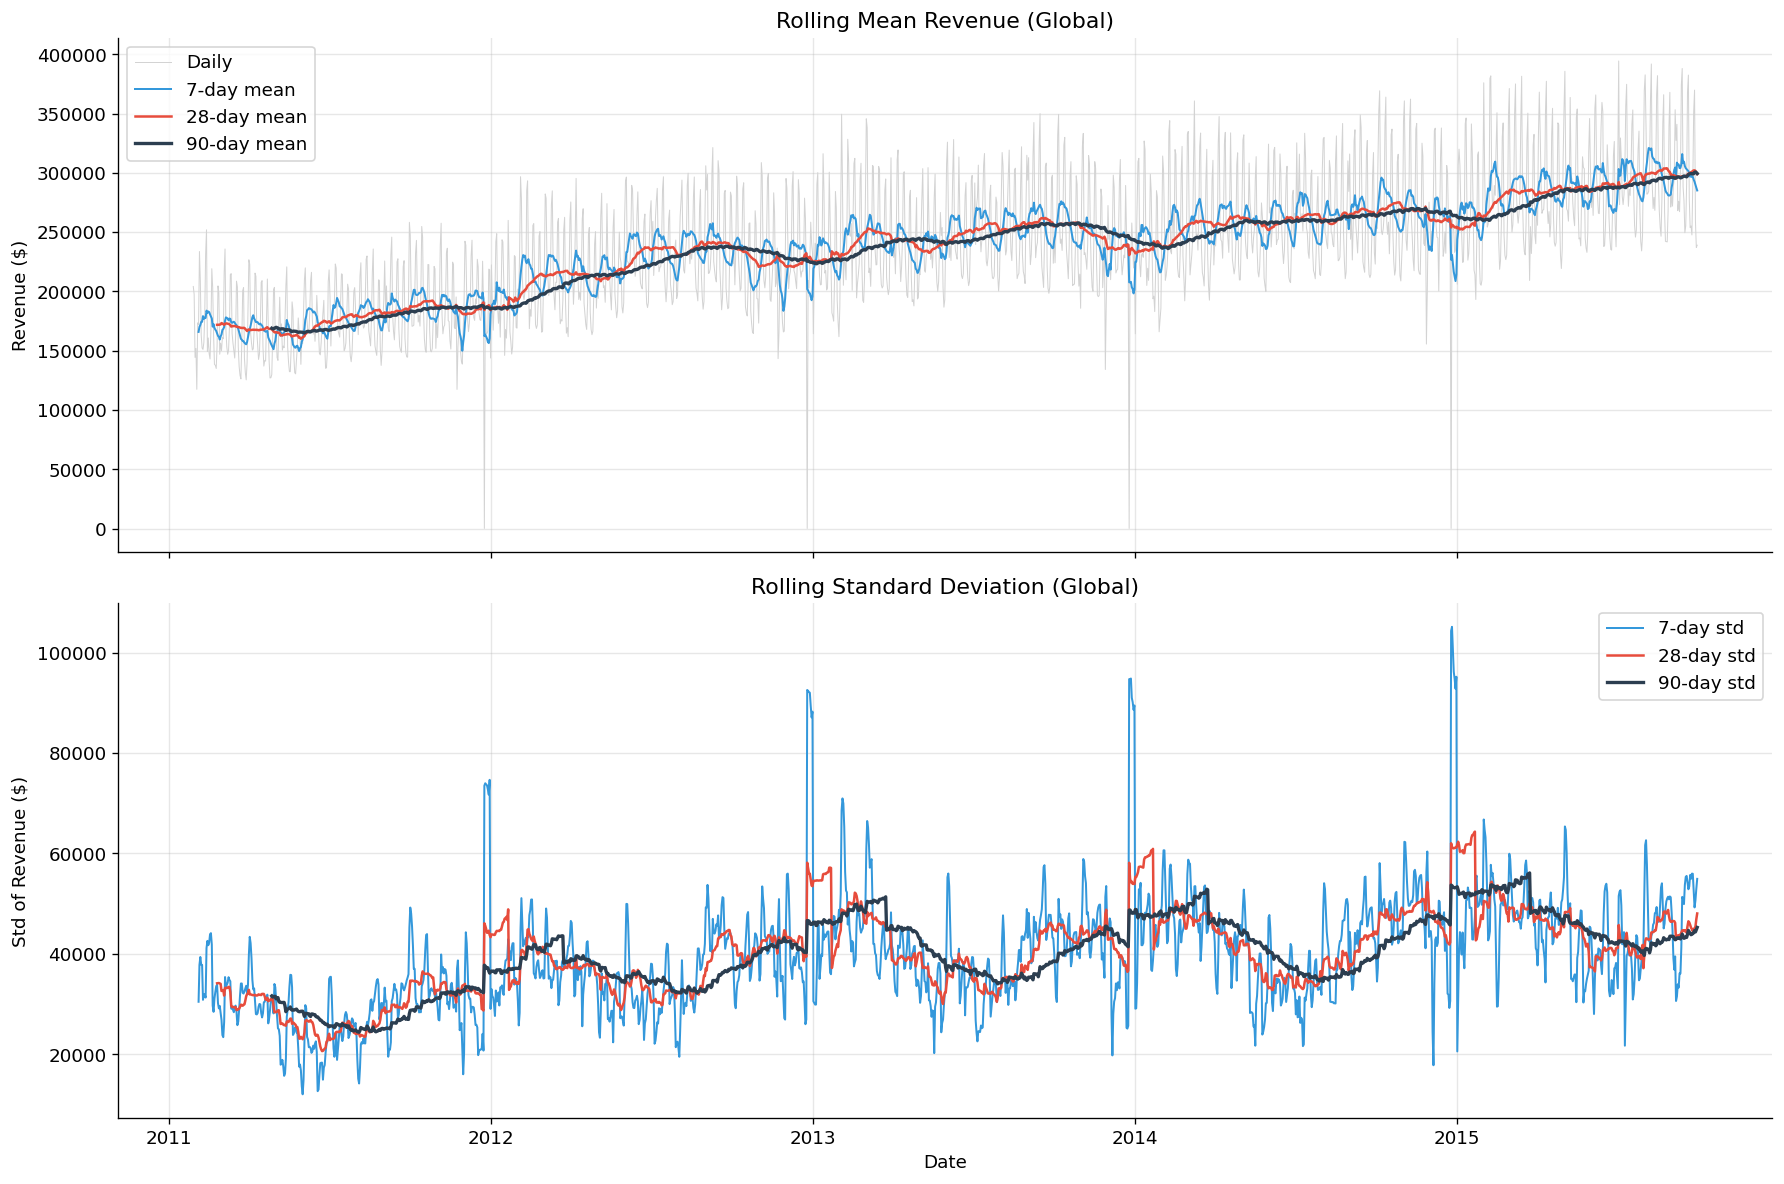

28-day rolling CV — mean : 0.169  |  std : 0.028
CV trend slope : -0.000005  |  R² : 0.008

► VERDICT: Process is STABLE — the variance process is roughly constant.


In [11]:
rev = global_df.set_index('date')['revenue'].sort_index()

roll7   = rev.rolling(7,   min_periods=7)
roll28  = rev.rolling(28,  min_periods=28)
roll90  = rev.rolling(90,  min_periods=90)

fig, axes = plt.subplots(2, 1, figsize=(15, 10), sharex=True)

# Rolling mean
axes[0].plot(rev.index, rev.values, color='lightgrey', lw=0.6, label='Daily')
axes[0].plot(roll7.mean(),  color='#3498db', lw=1.2, label='7-day mean')
axes[0].plot(roll28.mean(), color='#e74c3c', lw=1.5, label='28-day mean')
axes[0].plot(roll90.mean(), color='#2c3e50', lw=2.0, label='90-day mean')
axes[0].set_title('Rolling Mean Revenue (Global)')
axes[0].set_ylabel('Revenue ($)')
axes[0].legend()

# Rolling std
axes[1].plot(roll7.std(),  color='#3498db', lw=1.2, label='7-day std')
axes[1].plot(roll28.std(), color='#e74c3c', lw=1.5, label='28-day std')
axes[1].plot(roll90.std(), color='#2c3e50', lw=2.0, label='90-day std')
axes[1].set_title('Rolling Standard Deviation (Global)')
axes[1].set_ylabel('Std of Revenue ($)')
axes[1].set_xlabel('Date')
axes[1].legend()

plt.tight_layout()
plt.show()

# Coefficient of variation over time (28-day)
roll_cv = roll28.std() / roll28.mean()
cv_trend_slope, _, r_cv, _, _ = stats.linregress(np.arange(roll_cv.dropna().__len__()), roll_cv.dropna().values)

print(f"28-day rolling CV — mean : {roll_cv.mean():.3f}  |  std : {roll_cv.std():.3f}")
print(f"CV trend slope : {cv_trend_slope:+.6f}  |  R² : {r_cv**2:.3f}")
print()
if roll_cv.std() < 0.05:
    verdict = "STABLE — the variance process is roughly constant."
elif abs(cv_trend_slope) > 0.0001:
    verdict = "SLOWLY DRIFTING — variance is changing over time, consider log-transform or GARCH-like volatility modelling."
else:
    verdict = "MODERATELY VOLATILE — some variance clustering present."
print(f"► VERDICT: Process is {verdict}")

---
## 3. Store-Level Behaviour
### 3.1 Store Heterogeneity

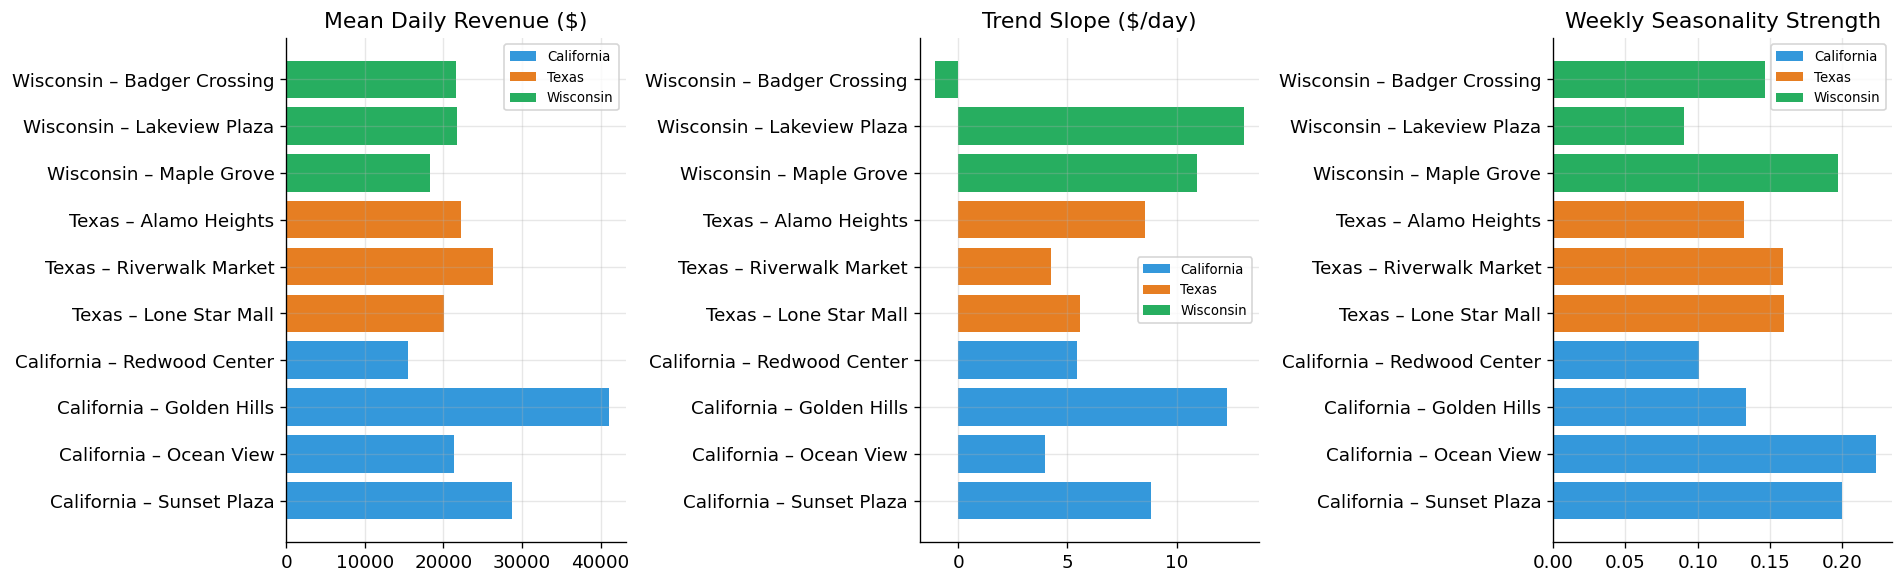

                 store_name      state   mean_rev     cv  trend_slope  trend_r2  seas_strength
  California – Golden Hills California 41134.3439 0.2246      12.3069    0.4305         0.1330
  California – Sunset Plaza California 28756.8980 0.2683       8.8055    0.3160         0.1997
   Texas – Riverwalk Market      Texas 26304.0400 0.2171       4.2575    0.1349         0.1589
      Texas – Alamo Heights      Texas 22268.3949 0.2601       8.5534    0.5293         0.1318
 Wisconsin – Lakeview Plaza  Wisconsin 21709.9159 0.3896      13.0598    0.5784         0.0902
Wisconsin – Badger Crossing  Wisconsin 21650.2898 0.2343      -1.0551    0.0105         0.1466
    California – Ocean View California 21393.6120 0.2729       3.9951    0.1136         0.2233
     Texas – Lone Star Mall      Texas 20081.2486 0.2359       5.5572    0.3341         0.1596
    Wisconsin – Maple Grove  Wisconsin 18289.5557 0.3866      10.9443    0.5815         0.1972
California – Redwood Center California 15469.1550 

In [12]:
# Compute per-store seasonality strength (ratio of seasonal amplitude to mean)
hetero_rows = []
for sid in store_ids:
    sub = stores_df[stores_df['store_id'] == sid].set_index('date')['revenue'].sort_index()
    # Trend slope
    x_n = np.arange(len(sub))
    sl, ic, r_tr, _, _ = stats.linregress(x_n, sub.values)
    # Weekly seasonality strength (std of dow means / overall mean)
    dow_means = stores_df[stores_df['store_id']==sid].groupby('dow')['revenue'].mean()
    seas_strength = dow_means.std() / sub.mean()
    hetero_rows.append({
        'store_id'   : sid,
        'store_name' : store_meta.loc[sid,'store_name'],
        'state'      : store_meta.loc[sid,'state'],
        'mean_rev'   : sub.mean(),
        'std_rev'    : sub.std(),
        'cv'         : sub.std()/sub.mean(),
        'trend_slope': sl,
        'trend_r2'   : r_tr**2,
        'seas_strength': seas_strength
    })

hetero = pd.DataFrame(hetero_rows)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, col, title in zip(axes,
                          ['mean_rev','trend_slope','seas_strength'],
                          ['Mean Daily Revenue ($)','Trend Slope ($/day)','Weekly Seasonality Strength']):
    bar_c = [colors_state[s] for s in hetero['state']]
    ax.barh(hetero['store_name'], hetero[col], color=bar_c)
    ax.set_title(title)
    ax.legend(handles=legend_elements, fontsize=8)

plt.tight_layout()
plt.show()

print(hetero[['store_name','state','mean_rev','cv','trend_slope','trend_r2','seas_strength']]
      .sort_values('mean_rev', ascending=False)
      .to_string(index=False, float_format='%.4f'))
print()
cv_range = hetero['mean_rev'].max() / hetero['mean_rev'].min()
print(f"Revenue range ratio (max/min mean): {cv_range:.2f}x")
print("► VERDICT: Stores are heterogeneous in both level and trend — store-specific features are warranted.")

### 3.2 Store Ranking Stability

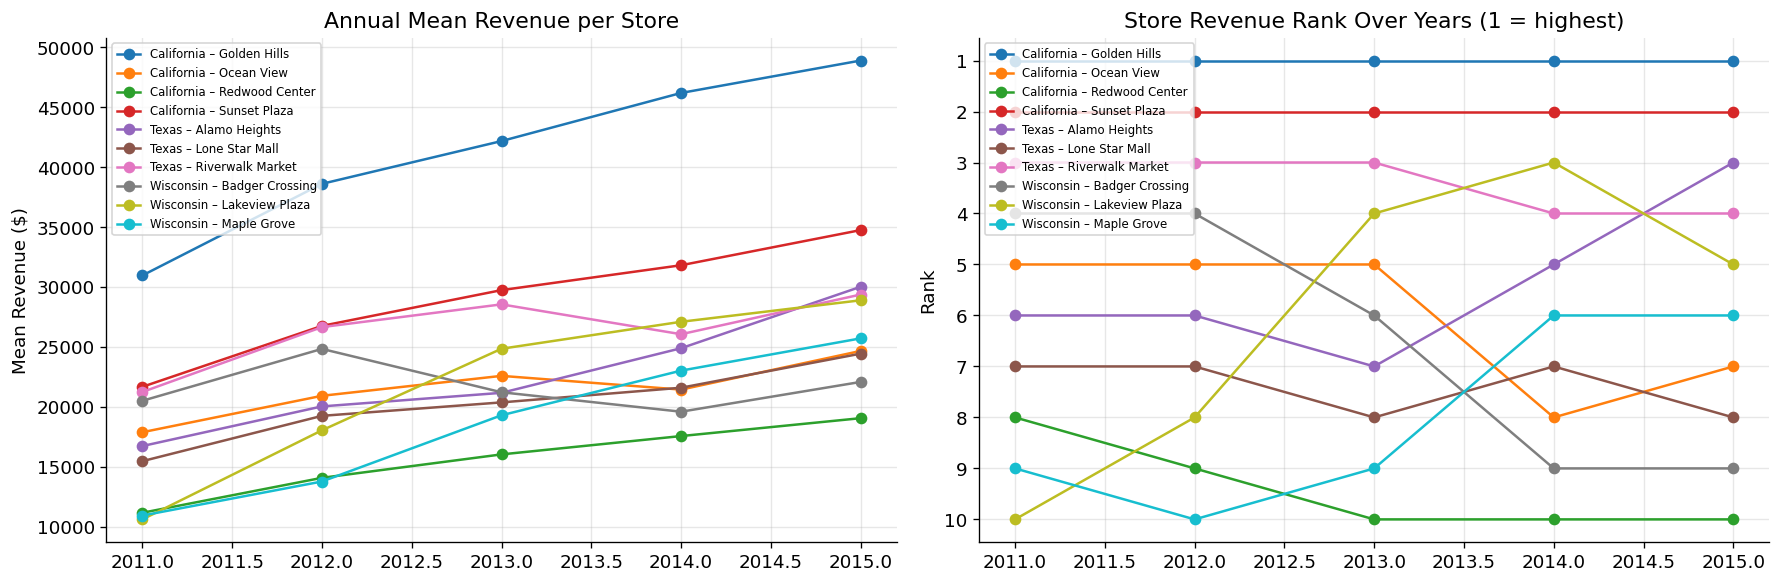

Rank standard deviation per store (0 = perfectly stable):
store_name
California – Golden Hills      0.000000
California – Sunset Plaza      0.000000
Texas – Lone Star Mall         0.547723
Texas – Riverwalk Market       0.547723
California – Redwood Center    0.894427
California – Ocean View        1.414214
Texas – Alamo Heights          1.516575
Wisconsin – Maple Grove        1.870829
Wisconsin – Badger Crossing    2.509980
Wisconsin – Lakeview Plaza     2.915476

5 / 10 stores maintain a stable rank over years.
► VERDICT: Rankings are UNSTABLE — store identity features are predictive.


In [13]:
annual_ranks = stores_df.groupby(['year','store_name'])['revenue'].mean().unstack()
annual_ranks_ranked = annual_ranks.rank(axis=1, ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Absolute revenue
for col in annual_ranks.columns:
    axes[0].plot(annual_ranks.index, annual_ranks[col], marker='o', label=col)
axes[0].set_title('Annual Mean Revenue per Store')
axes[0].set_ylabel('Mean Revenue ($)')
axes[0].legend(fontsize=7)

# Rank over years (bump chart)
for col in annual_ranks_ranked.columns:
    axes[1].plot(annual_ranks_ranked.index, annual_ranks_ranked[col], marker='o', label=col)
axes[1].invert_yaxis()
axes[1].set_title('Store Revenue Rank Over Years (1 = highest)')
axes[1].set_ylabel('Rank')
axes[1].set_yticks(range(1, len(store_ids)+1))
axes[1].legend(fontsize=7)

plt.tight_layout()
plt.show()

rank_std = annual_ranks_ranked.std()
print("Rank standard deviation per store (0 = perfectly stable):")
print(rank_std.sort_values().to_string())
stable = (rank_std < 1).sum()
print(f"\n{stable} / {len(store_ids)} stores maintain a stable rank over years.")
print("► VERDICT: Rankings are " + ("STABLE" if stable > len(store_ids)//2 else "UNSTABLE") + 
      " — store identity features are predictive.")

### 3.3 Store vs Global Correlation

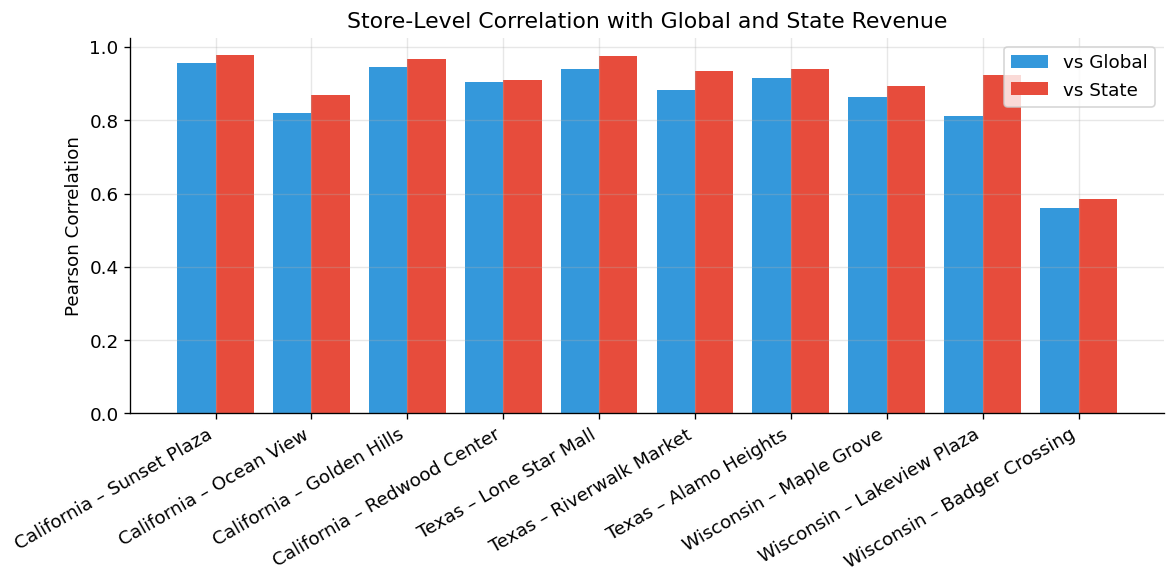

                      store      state  corr_global  corr_state
  California – Sunset Plaza California       0.9564      0.9770
    California – Ocean View California       0.8200      0.8698
  California – Golden Hills California       0.9457      0.9680
California – Redwood Center California       0.9058      0.9114
     Texas – Lone Star Mall      Texas       0.9393      0.9761
   Texas – Riverwalk Market      Texas       0.8830      0.9341
      Texas – Alamo Heights      Texas       0.9160      0.9397
    Wisconsin – Maple Grove  Wisconsin       0.8634      0.8942
 Wisconsin – Lakeview Plaza  Wisconsin       0.8110      0.9247
Wisconsin – Badger Crossing  Wisconsin       0.5612      0.5859

Average corr with global : 0.8602
Average corr with state  : 0.8981
► VERDICT: Global and state aggregates are strong signals — hierarchical features will be useful.


In [14]:
global_rev = global_df.set_index('date')['revenue'].rename('global')

# State aggregates
state_rev = stores_df.groupby(['date','state'])['revenue'].sum().unstack()

corr_rows = []
for sid in store_ids:
    sub = stores_df[stores_df['store_id']==sid].set_index('date')['revenue']
    state = store_meta.loc[sid,'state']
    corr_global = sub.corr(global_rev)
    corr_state  = sub.corr(state_rev[state])
    corr_rows.append({'store': store_meta.loc[sid,'store_name'], 'state': state,
                      'corr_global': corr_global, 'corr_state': corr_state})

corr_df = pd.DataFrame(corr_rows)

fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(corr_df))
ax.bar(x - 0.2, corr_df['corr_global'], 0.4, label='vs Global', color='#3498db')
ax.bar(x + 0.2, corr_df['corr_state'],  0.4, label='vs State',  color='#e74c3c')
ax.set_xticks(x)
ax.set_xticklabels(corr_df['store'], rotation=30, ha='right')
ax.set_title('Store-Level Correlation with Global and State Revenue')
ax.set_ylabel('Pearson Correlation')
ax.legend()
plt.tight_layout()
plt.show()

print(corr_df.to_string(index=False, float_format='%.4f'))
avg_global = corr_df['corr_global'].mean()
avg_state  = corr_df['corr_state'].mean()
print(f"\nAverage corr with global : {avg_global:.4f}")
print(f"Average corr with state  : {avg_state:.4f}")
print("► VERDICT: " + 
      ("Global and state aggregates are strong signals — hierarchical features will be useful." 
       if avg_global > 0.7 else "Aggregated signals have limited predictive value for individual stores."))

---
## 4. Event Analysis
### 4.1 Event Uplift

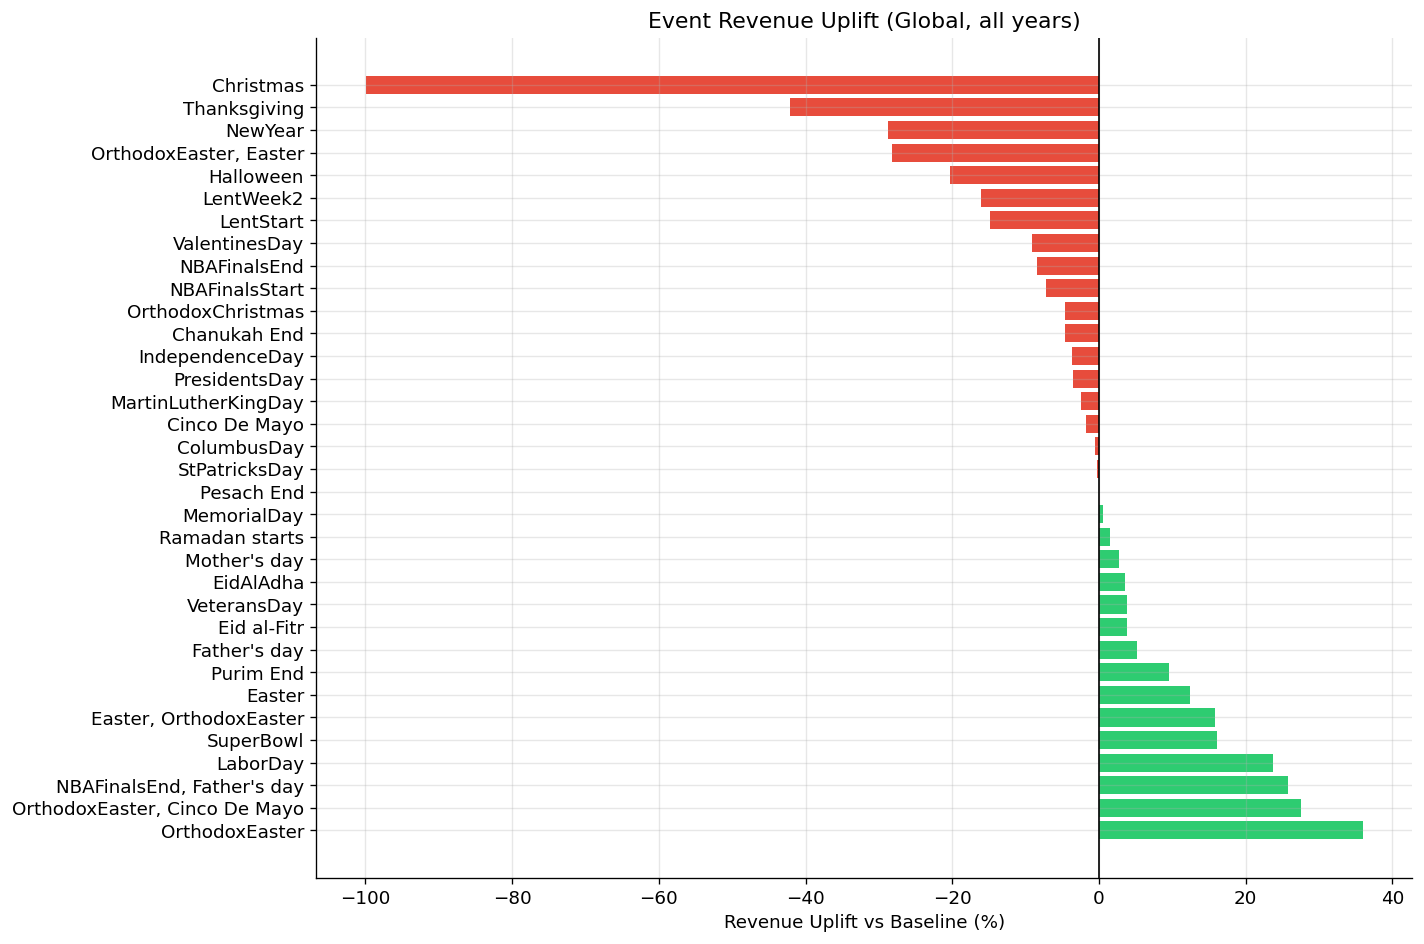

Baseline (non-event) mean revenue: $237,943

                        event  mean_rev  uplift_pct  n_obs
               OrthodoxEaster  323437.8        35.9      2
OrthodoxEaster, Cinco De Mayo  303506.2        27.6      1
   NBAFinalsEnd, Father's day  299362.6        25.8      1
                     LaborDay  294542.8        23.8      5
                    SuperBowl  276162.2        16.1      5
       Easter, OrthodoxEaster  275721.2        15.9      1
                       Easter  267559.6        12.4      3
                    Purim End  260640.4         9.5      5
                 Father's day  250426.0         5.2      4
                  Eid al-Fitr  247108.1         3.9      5
                  VeteransDay  247069.5         3.8      4
                    EidAlAdha  246525.1         3.6      5
                 Mother's day  244409.7         2.7      5
               Ramadan starts  241370.5         1.4      5
                  MemorialDay  239134.0         0.5      5
           

In [15]:
# Merge events onto global_df
event_global = global_df.merge(events.rename(columns={'date':'date'}), on='date', how='left')
event_global['is_event'] = event_global['event'].notna()

baseline = event_global[~event_global['is_event']]['revenue'].mean()

event_uplift = []
for evt in events['event'].unique():
    evt_dates = events[events['event'] == evt]['date']
    evt_rev   = event_global[event_global['date'].isin(evt_dates)]['revenue']
    if len(evt_rev) > 0:
        event_uplift.append({'event': evt, 'mean_rev': evt_rev.mean(),
                             'uplift_pct': 100*(evt_rev.mean()/baseline - 1),
                             'n_obs': len(evt_rev)})

uplift_df = pd.DataFrame(event_uplift).sort_values('uplift_pct', ascending=False)

fig, ax = plt.subplots(figsize=(12, 8))
colors_up = ['#2ecc71' if x >= 0 else '#e74c3c' for x in uplift_df['uplift_pct']]
ax.barh(uplift_df['event'], uplift_df['uplift_pct'], color=colors_up)
ax.axvline(0, color='black', lw=1)
ax.set_xlabel('Revenue Uplift vs Baseline (%)')
ax.set_title('Event Revenue Uplift (Global, all years)')
plt.tight_layout()
plt.show()

print(f"Baseline (non-event) mean revenue: ${baseline:,.0f}")
print()
print(uplift_df.to_string(index=False, float_format='%.1f'))
n_pos = (uplift_df['uplift_pct'] > 5).sum()
n_neg = (uplift_df['uplift_pct'] < -5).sum()
print(f"\nEvents with >5% positive uplift : {n_pos}")
print(f"Events with >5% negative uplift : {n_neg}")
print("► VERDICT: Event features are highly valuable — at least some events produce significant revenue shifts.")

### 4.2 Event Window Analysis (Build-up & Decay)

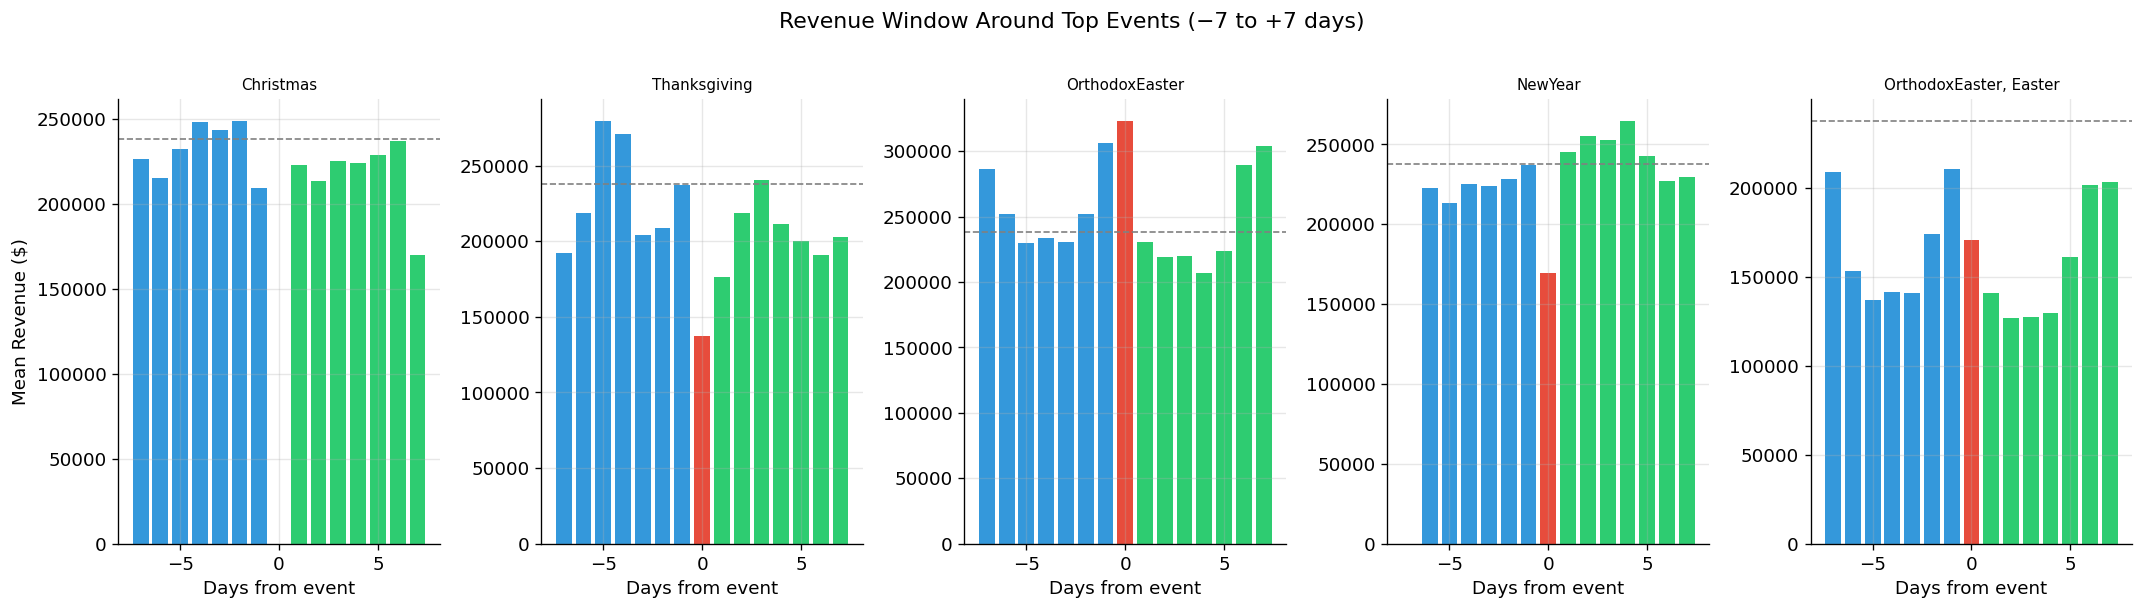

Window analysis (averaged across all occurrences):
Christmas                  pre=$   231,906  day0=$        75  post=$   217,133
Thanksgiving               pre=$   230,136  day0=$   137,573  post=$   205,817
OrthodoxEaster             pre=$   255,859  day0=$   323,438  post=$   241,935
NewYear                    pre=$   192,918  day0=$   169,580  post=$   245,244
OrthodoxEaster, Easter     pre=$   166,647  day0=$   170,691  post=$   155,895


In [16]:
# Pick top 5 events by absolute uplift for window analysis
top_events = uplift_df.reindex(uplift_df['uplift_pct'].abs().sort_values(ascending=False).index).head(5)['event'].tolist()

fig, axes = plt.subplots(1, len(top_events), figsize=(18, 5), sharey=False)

global_indexed = global_df.set_index('date')['revenue']

for ax, evt in zip(axes, top_events):
    evt_dates = events[events['event'] == evt]['date'].tolist()
    windows = []
    for d in evt_dates:
        for offset in range(-7, 8):
            target_date = d + pd.Timedelta(days=offset)
            if target_date in global_indexed.index:
                windows.append({'offset': offset, 'revenue': global_indexed[target_date]})
    if not windows:
        continue
    wdf = pd.DataFrame(windows).groupby('offset')['revenue'].mean()
    bar_c = ['#e74c3c' if i == 0 else ('#3498db' if i < 0 else '#2ecc71')
             for i in wdf.index]
    ax.bar(wdf.index, wdf.values, color=bar_c)
    ax.axhline(baseline, color='grey', ls='--', lw=1, label='Baseline')
    ax.set_title(evt, fontsize=9)
    ax.set_xlabel('Days from event')
    if ax == axes[0]: ax.set_ylabel('Mean Revenue ($)')

plt.suptitle('Revenue Window Around Top Events (−7 to +7 days)', y=1.01)
plt.tight_layout()
plt.show()

print("Window analysis (averaged across all occurrences):")
for evt in top_events:
    evt_dates = events[events['event'] == evt]['date'].tolist()
    pre  = []
    day0 = []
    post = []
    for d in evt_dates:
        for offset in range(-7,0):
            td = d + pd.Timedelta(days=offset)
            if td in global_indexed.index: pre.append(global_indexed[td])
        if d in global_indexed.index: day0.append(global_indexed[d])
        for offset in range(1,8):
            td = d + pd.Timedelta(days=offset)
            if td in global_indexed.index: post.append(global_indexed[td])
    print(f"{evt:<25}  pre=${np.mean(pre):>10,.0f}  day0=${np.mean(day0):>10,.0f}  post=${np.mean(post):>10,.0f}")

### 4.3 Event Consistency Across Years

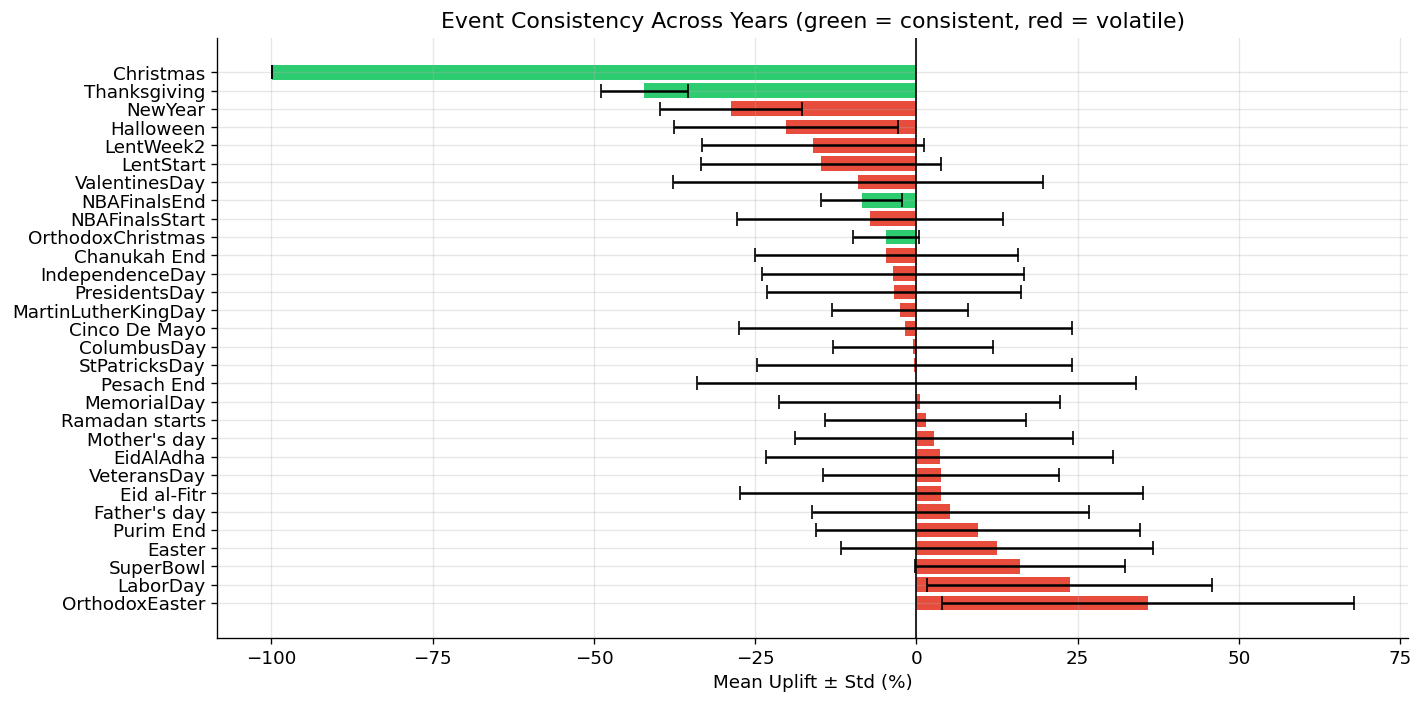

Recurring events analysed : 30
Consistent events (<10pp std) : 4

              event  years  mean_uplift  std_uplift  consistent
     OrthodoxEaster      2         35.9        32.0       False
           LaborDay      5         23.8        22.1       False
          SuperBowl      5         16.1        16.3       False
             Easter      3         12.4        24.2       False
          Purim End      5          9.5        25.1       False
       Father's day      4          5.2        21.5       False
        Eid al-Fitr      5          3.9        31.2       False
        VeteransDay      4          3.8        18.3       False
          EidAlAdha      5          3.6        26.9       False
       Mother's day      5          2.7        21.6       False
     Ramadan starts      5          1.4        15.6       False
        MemorialDay      5          0.5        21.8       False
         Pesach End      5         -0.0        34.0       False
      StPatricksDay      5         -0.

In [17]:
events_with_year = events.copy()
events_with_year['year'] = events_with_year['date'].dt.year
recurring = events_with_year.groupby('event').filter(lambda x: len(x) >= 3)['event'].unique()

consist_rows = []
for evt in recurring:
    by_year = []
    for _, row in events[events['event']==evt].iterrows():
        if row['date'] in global_indexed.index:
            by_year.append({'year': row['date'].year,
                            'uplift': 100*(global_indexed[row['date']]/baseline - 1)})
    if by_year:
        df_byr = pd.DataFrame(by_year)
        consist_rows.append({'event': evt,
                             'years': len(df_byr),
                             'mean_uplift': df_byr['uplift'].mean(),
                             'std_uplift': df_byr['uplift'].std(),
                             'consistent': df_byr['uplift'].std() < 10})

consist_df = pd.DataFrame(consist_rows).sort_values('mean_uplift', ascending=False)

fig, ax = plt.subplots(figsize=(12, 6))
err_colors = ['#2ecc71' if c else '#e74c3c' for c in consist_df['consistent']]
ax.barh(consist_df['event'], consist_df['mean_uplift'],
        xerr=consist_df['std_uplift'], color=err_colors, capsize=4)
ax.axvline(0, color='black', lw=1)
ax.set_xlabel('Mean Uplift ± Std (%)')
ax.set_title('Event Consistency Across Years (green = consistent, red = volatile)')
plt.tight_layout()
plt.show()

n_consistent = consist_df['consistent'].sum()
print(f"Recurring events analysed : {len(consist_df)}")
print(f"Consistent events (<10pp std) : {n_consistent}")
print()
print(consist_df.to_string(index=False, float_format='%.1f'))
print()
print("► VERDICT: " + 
      ("Most events are consistent year-over-year — they are reliable features."
       if n_consistent/len(consist_df) > 0.5
       else "High variance in event effects — consider event×year interaction terms."))

### 4.4 Store × Event Interaction

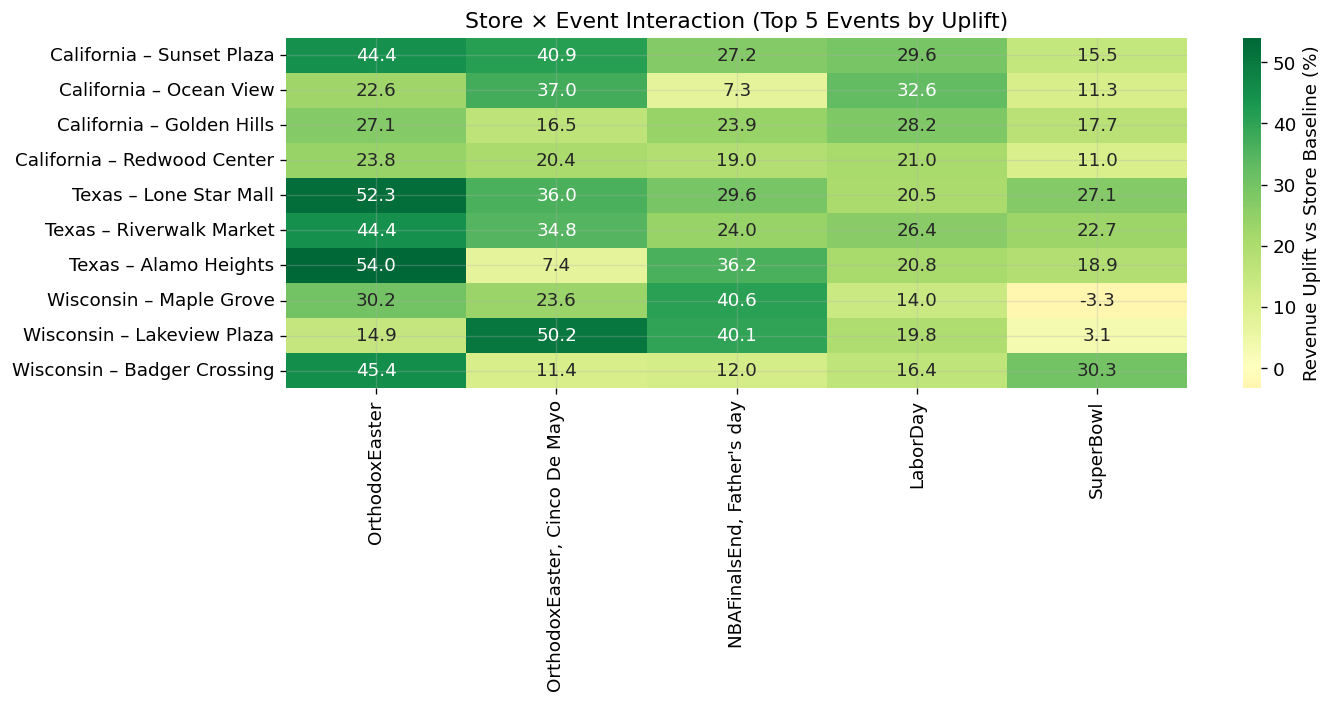

Cross-store variation per event (std of uplift %):
  OrthodoxEaster                 std = 13.8pp
  OrthodoxEaster, Cinco De Mayo  std = 14.0pp
  NBAFinalsEnd, Father's day     std = 11.2pp
  LaborDay                       std = 6.0pp
  SuperBowl                      std = 10.4pp

Average cross-store std across top events: 11.1pp
► VERDICT: Store×Event interactions are significant — interaction features are recommended.


In [18]:
# Merge events onto stores_df
store_event = stores_df.merge(events, on='date', how='left')
store_event['is_event'] = store_event['event'].notna()

# Per-store baseline
store_baselines = store_event[~store_event['is_event']].groupby('store_id')['revenue'].mean()

# Compute uplift per store per event
top_5_events = uplift_df.head(5)['event'].tolist()
interaction_matrix = pd.DataFrame(index=store_ids,
                                   columns=top_5_events, dtype=float)

for sid in store_ids:
    for evt in top_5_events:
        evt_dates = events[events['event']==evt]['date']
        evt_rev   = store_event[(store_event['store_id']==sid) &
                                 (store_event['date'].isin(evt_dates))]['revenue']
        if len(evt_rev) > 0:
            interaction_matrix.loc[sid, evt] = 100*(evt_rev.mean()/store_baselines[sid] - 1)

interaction_matrix.index = [store_meta.loc[s,'store_name'] for s in store_ids]
interaction_matrix = interaction_matrix.astype(float)

fig, ax = plt.subplots(figsize=(12, 6))
sns.heatmap(interaction_matrix, annot=True, fmt='.1f', cmap='RdYlGn', center=0,
            ax=ax, cbar_kws={'label': 'Revenue Uplift vs Store Baseline (%)'})
ax.set_title('Store × Event Interaction (Top 5 Events by Uplift)')
plt.tight_layout()
plt.show()

# Variation across stores per event
print("Cross-store variation per event (std of uplift %):")
for evt in top_5_events:
    std_ = interaction_matrix[evt].std()
    print(f"  {evt:<30} std = {std_:.1f}pp")
print()
avg_interaction_std = interaction_matrix.std(axis=0).mean()
print(f"Average cross-store std across top events: {avg_interaction_std:.1f}pp")
print("► VERDICT: " +
      ("Store×Event interactions are significant — interaction features are recommended."
       if avg_interaction_std > 5
       else "Event effects are relatively uniform across stores — global event features suffice."))

---
## 5. Lag Structure Analysis
### 5.1 Autocorrelation (ACF & PACF)

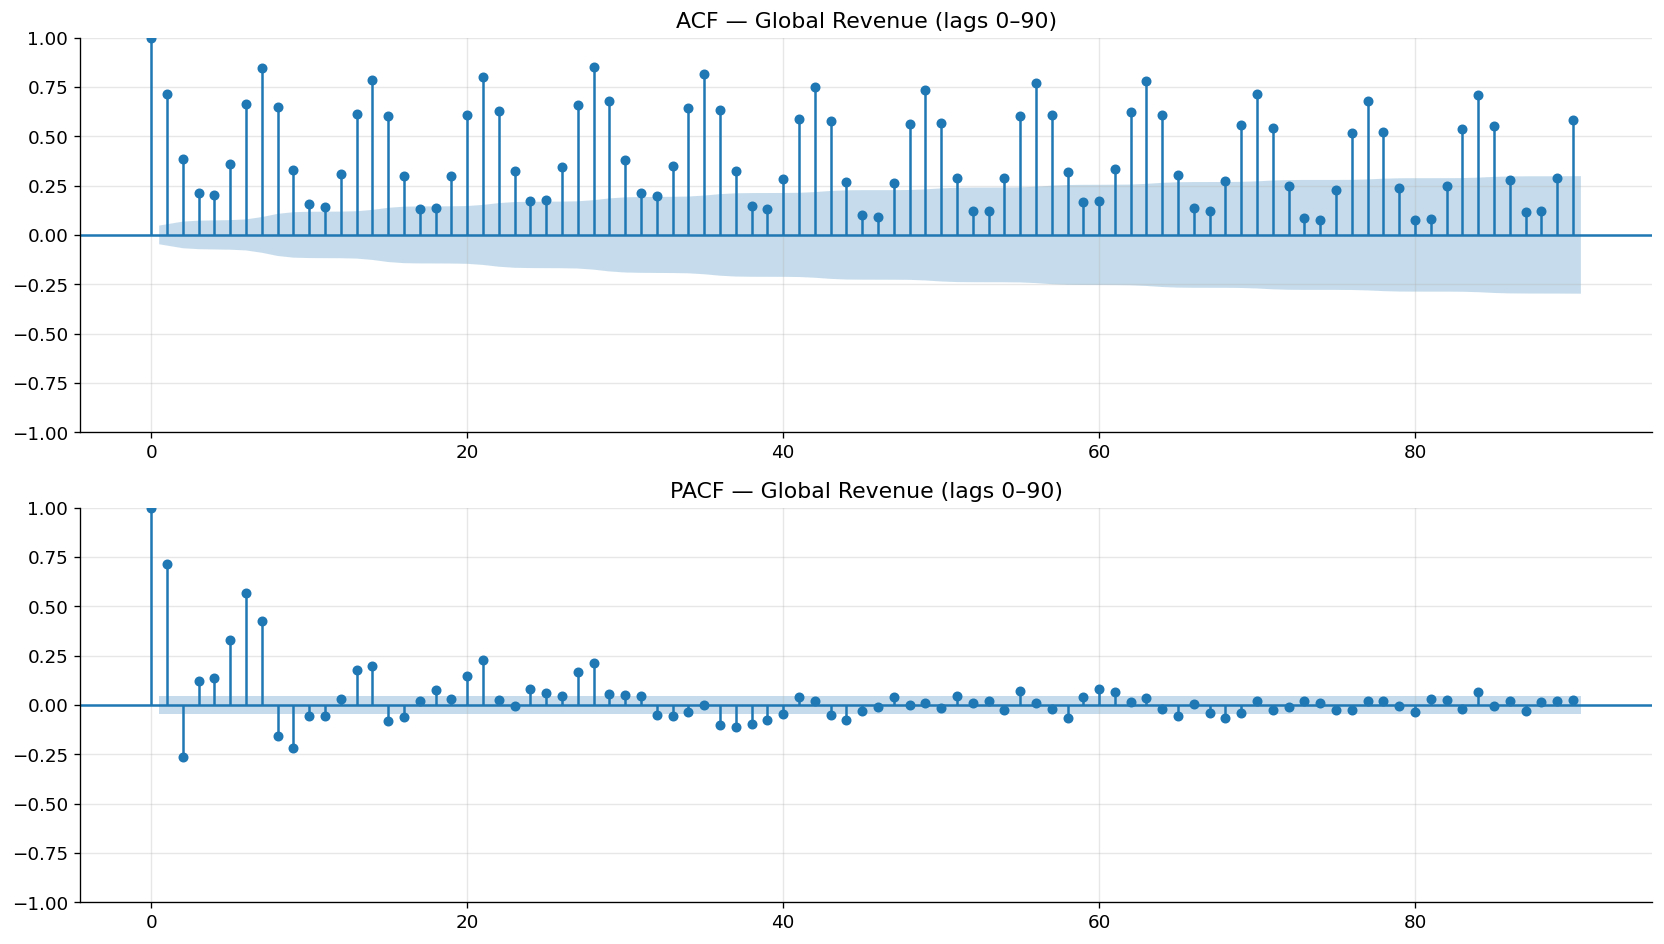

   Lag       ACF  Interpretation
--------------------------------------------------
     1    0.7162  *** significant
     7    0.8438  *** significant
    14    0.7872  *** significant
    28    0.8485  *** significant
    90    0.5806  *** significant
   365    0.3613  *** significant

95% CI threshold: ±0.0475
Significant lags : [1, 7, 14, 28, 90, 365]
► VERDICT: Lag features at lags [1, 7, 14, 28, 90, 365] are predictive. Include as autoregressive features.


In [19]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

rev_clean = global_df.set_index('date')['revenue'].sort_index()

fig, axes = plt.subplots(2, 1, figsize=(14, 8))
plot_acf( rev_clean, lags=90, ax=axes[0], title='ACF — Global Revenue (lags 0–90)', alpha=0.05)
plot_pacf(rev_clean, lags=90, ax=axes[1], title='PACF — Global Revenue (lags 0–90)', alpha=0.05)
plt.tight_layout()
plt.show()

# Compute ACF values at key lags
acf_vals = acf(rev_clean, nlags=400, fft=True)
key_lags = [1, 7, 14, 28, 90, 365]
print(f"{'Lag':>6}  {'ACF':>8}  {'Interpretation'}")
print('-' * 50)
ci = 1.96 / np.sqrt(len(rev_clean))
for lag in key_lags:
    if lag < len(acf_vals):
        val = acf_vals[lag]
        sig = '*** significant' if abs(val) > ci else 'not significant'
        print(f"{lag:>6}  {val:>8.4f}  {sig}")

print(f"\n95% CI threshold: ±{ci:.4f}")
strong_lags = [l for l in key_lags if l < len(acf_vals) and abs(acf_vals[l]) > ci]
print(f"Significant lags : {strong_lags}")
print("► VERDICT: Lag features at lags " + str(strong_lags) + " are predictive. Include as autoregressive features.")

### 5.2 Rolling Predictability

     7-day window Ridge R² on hold-out : 0.6168
    28-day window Ridge R² on hold-out : 0.7474
    90-day window Ridge R² on hold-out : 0.7585


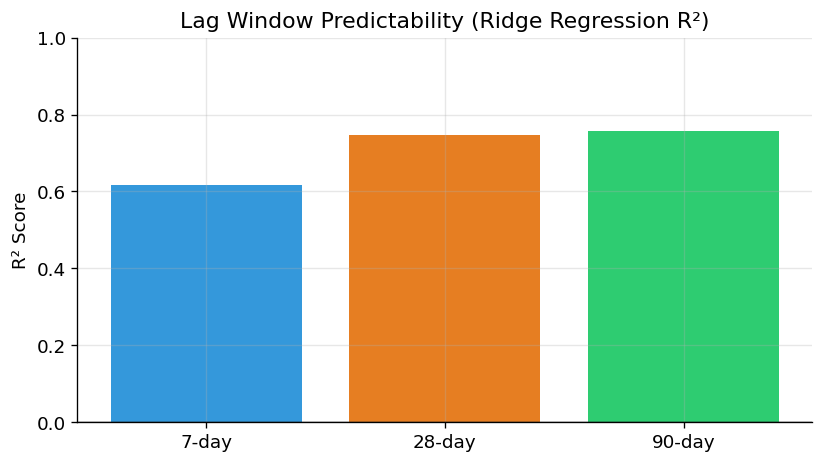


Best window: 90-day (R²=0.7585)
► VERDICT: 90-day lag window provides strong predictive power — AR features from this window should be included.


In [20]:
from sklearn.linear_model import Ridge
from sklearn.metrics import r2_score

rev_series = global_df.set_index('date')['revenue'].sort_index().reset_index(drop=True)

results = {}
for window, label in [(7,'7-day'),(28,'28-day'),(90,'90-day')]:
    X, y = [], []
    for i in range(window, len(rev_series)):
        X.append(rev_series.iloc[i-window:i].values)
        y.append(rev_series.iloc[i])
    X, y = np.array(X), np.array(y)
    split = int(len(X) * 0.8)
    model = Ridge(alpha=1.0).fit(X[:split], y[:split])
    preds = model.predict(X[split:])
    r2 = r2_score(y[split:], preds)
    results[label] = r2
    print(f"{label:>10} window Ridge R² on hold-out : {r2:.4f}")

fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(list(results.keys()), list(results.values()),
       color=['#3498db','#e67e22','#2ecc71'])
ax.axhline(0, color='black', lw=0.8)
ax.set_ylim(0, 1)
ax.set_ylabel('R² Score')
ax.set_title('Lag Window Predictability (Ridge Regression R²)')
plt.tight_layout()
plt.show()

best_window = max(results, key=results.get)
print(f"\nBest window: {best_window} (R²={results[best_window]:.4f})")
print("► VERDICT: " +
      (f"{best_window} lag window provides strong predictive power — AR features from this window should be included."
       if results[best_window] > 0.5
       else "Lag windows alone have limited predictive power — calendar and event features are likely more valuable."))

---
## 6. Hierarchical Structure Analysis
### 6.1 State-Level Behaviour

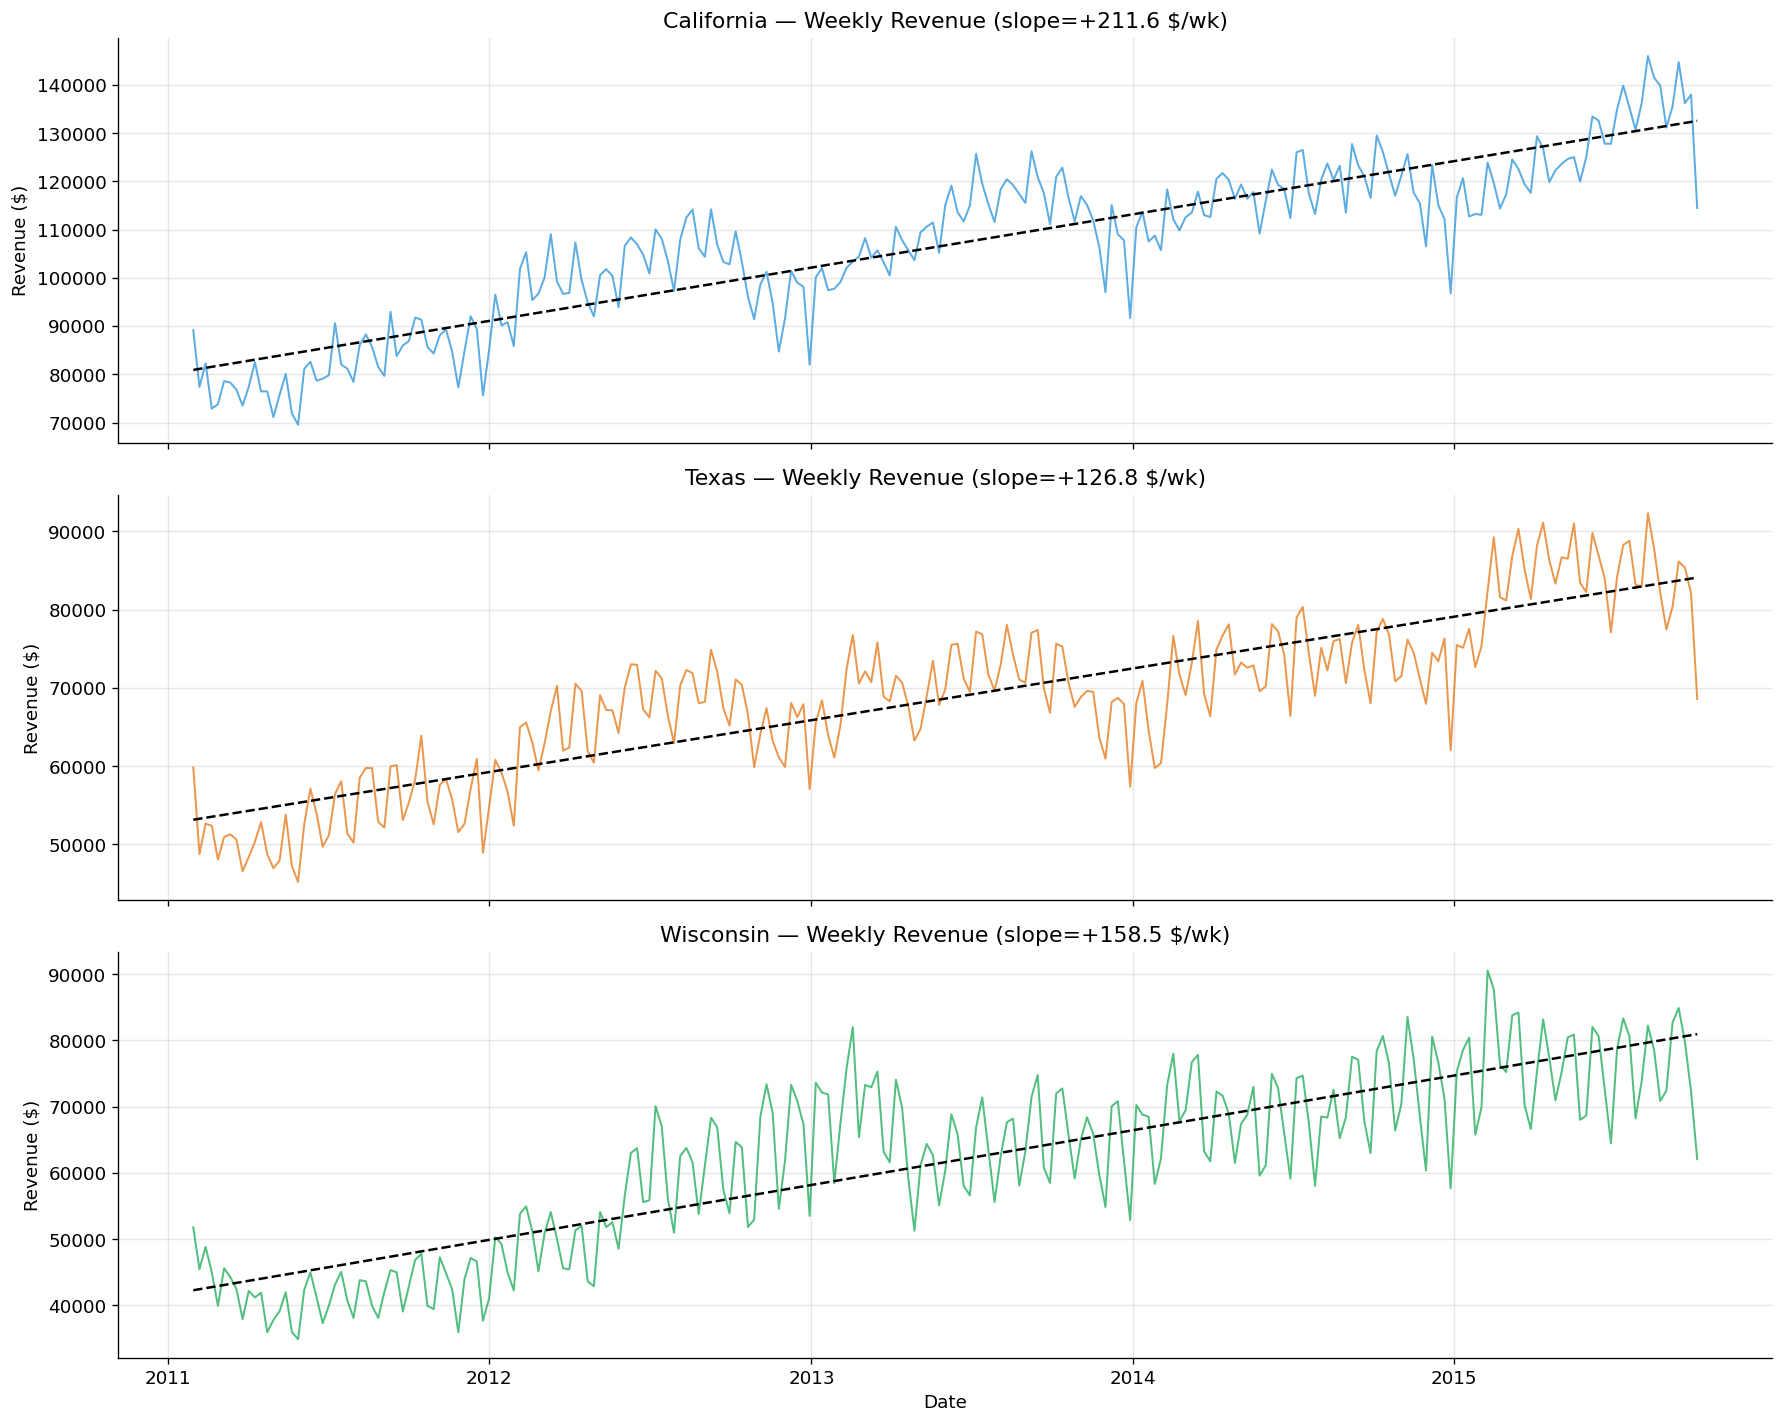

State-level summary:
  California       mean=$   106,754  trend=   +30.6/day  weekly_seas=0.1623  R²_trend=0.371
  Texas            mean=$    68,654  trend=   +18.4/day  weekly_seas=0.1498  R²_trend=0.345
  Wisconsin        mean=$    61,650  trend=   +22.9/day  weekly_seas=0.1406  R²_trend=0.436

► VERDICT: States differ in trend and level — state identity is a useful grouping feature.


In [21]:
state_daily = stores_df.groupby(['date','state'])['revenue'].sum().unstack().sort_index()

fig, axes = plt.subplots(3, 1, figsize=(15, 12), sharex=True)
states = state_daily.columns.tolist()
state_colors = {'California': '#3498db', 'Texas': '#e67e22', 'Wisconsin': '#27ae60'}

for ax, state in zip(axes, states):
    weekly = state_daily[state].resample('W').mean()
    ax.plot(weekly.index, weekly.values, color=state_colors[state], lw=1.2, alpha=0.8)
    # Trend
    x_n = np.arange(len(weekly))
    sl, ic, _, _, _ = stats.linregress(x_n, weekly.values)
    ax.plot(weekly.index, ic + sl * x_n, color='black', ls='--', lw=1.5)
    ax.set_title(f'{state} — Weekly Revenue (slope={sl:+.1f} $/wk)')
    ax.set_ylabel('Revenue ($)')

axes[-1].set_xlabel('Date')
plt.tight_layout()
plt.show()

print("State-level summary:")
for state in states:
    s = state_daily[state]
    dow_s  = stores_df[stores_df['state']==state].groupby('dow')['revenue'].mean()
    seas   = dow_s.std() / dow_s.mean()
    sl, _, r_, _, _ = stats.linregress(np.arange(len(s)), s.values)
    print(f"  {state:<15}  mean=${s.mean():>10,.0f}  trend={sl:>+8.1f}/day  weekly_seas={seas:.4f}  R²_trend={r_**2:.3f}")
print()
print("► VERDICT: States differ in trend and level — state identity is a useful grouping feature.")

### 6.2 Cross-State Relationships

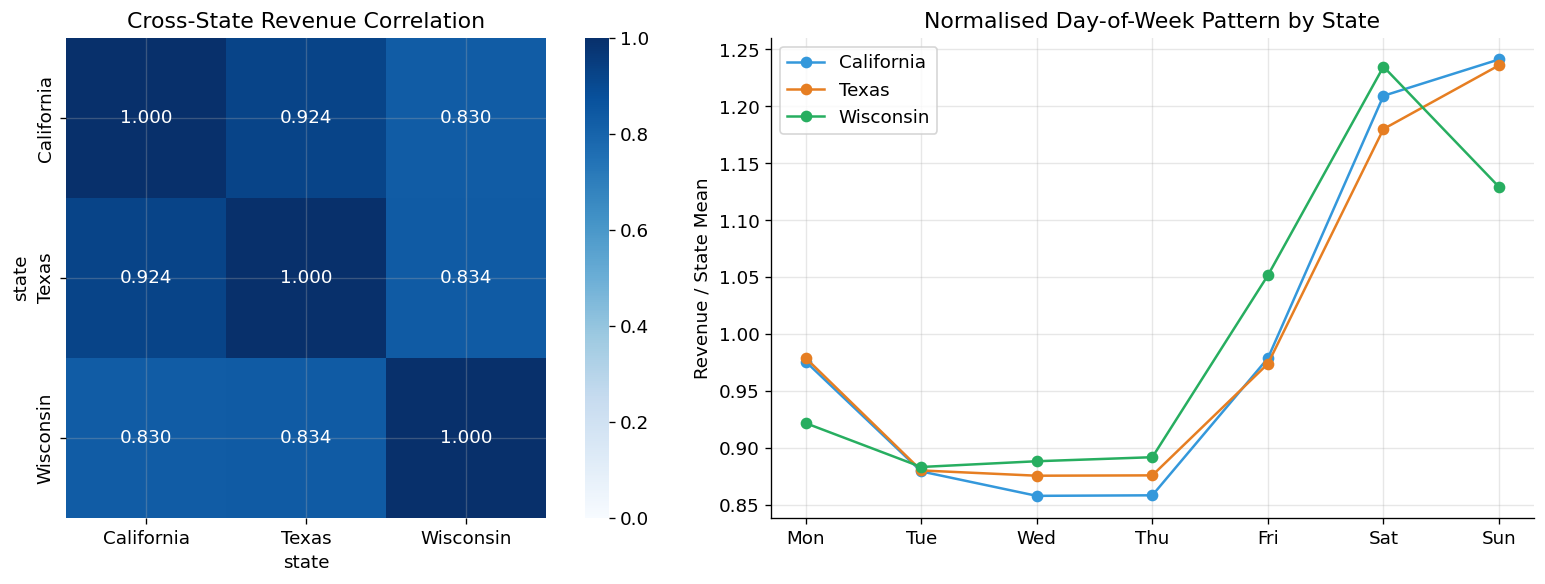

Cross-state correlation range: 0.830 – 0.924
California       avg event uplift: -4.7%
Texas            avg event uplift: -1.3%
Wisconsin        avg event uplift: -8.3%

► VERDICT: States are highly correlated — shared hierarchical signals exist at the state level.


In [22]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Correlation matrix
state_corr = state_daily.corr()
sns.heatmap(state_corr, annot=True, fmt='.3f', cmap='Blues', vmin=0, vmax=1,
            ax=axes[0], square=True)
axes[0].set_title('Cross-State Revenue Correlation')

# Shared day-of-week pattern
for state in states:
    dow_m = stores_df[stores_df['state']==state].groupby('dow')['revenue'].mean()
    dow_norm = dow_m / dow_m.mean()
    axes[1].plot(range(7), dow_norm.values, marker='o',
                 color=state_colors[state], label=state)
axes[1].set_xticks(range(7))
axes[1].set_xticklabels(['Mon','Tue','Wed','Thu','Fri','Sat','Sun'])
axes[1].set_title('Normalised Day-of-Week Pattern by State')
axes[1].set_ylabel('Revenue / State Mean')
axes[1].legend()
plt.tight_layout()
plt.show()

min_corr = state_corr.values[np.triu_indices(len(states), k=1)].min()
max_corr = state_corr.values[np.triu_indices(len(states), k=1)].max()
print(f"Cross-state correlation range: {min_corr:.3f} – {max_corr:.3f}")

# Shared event response
event_state_uplift = {}
for state in states:
    sub = stores_df[stores_df['state']==state].groupby('date')['revenue'].sum()
    state_base = sub[~sub.index.isin(events['date'])].mean()
    uplifts = []
    for d in events['date']:
        if d in sub.index:
            uplifts.append(100*(sub[d]/state_base - 1))
    event_state_uplift[state] = np.mean(uplifts)
    print(f"{state:<15}  avg event uplift: {event_state_uplift[state]:+.1f}%")

print()
print("► VERDICT: " +
      ("States are highly correlated — shared hierarchical signals exist at the state level."
       if min_corr > 0.8 else "States diverge — state-specific models or embeddings may be preferable."))

### 6.3 Global Aggregate (Store 0)

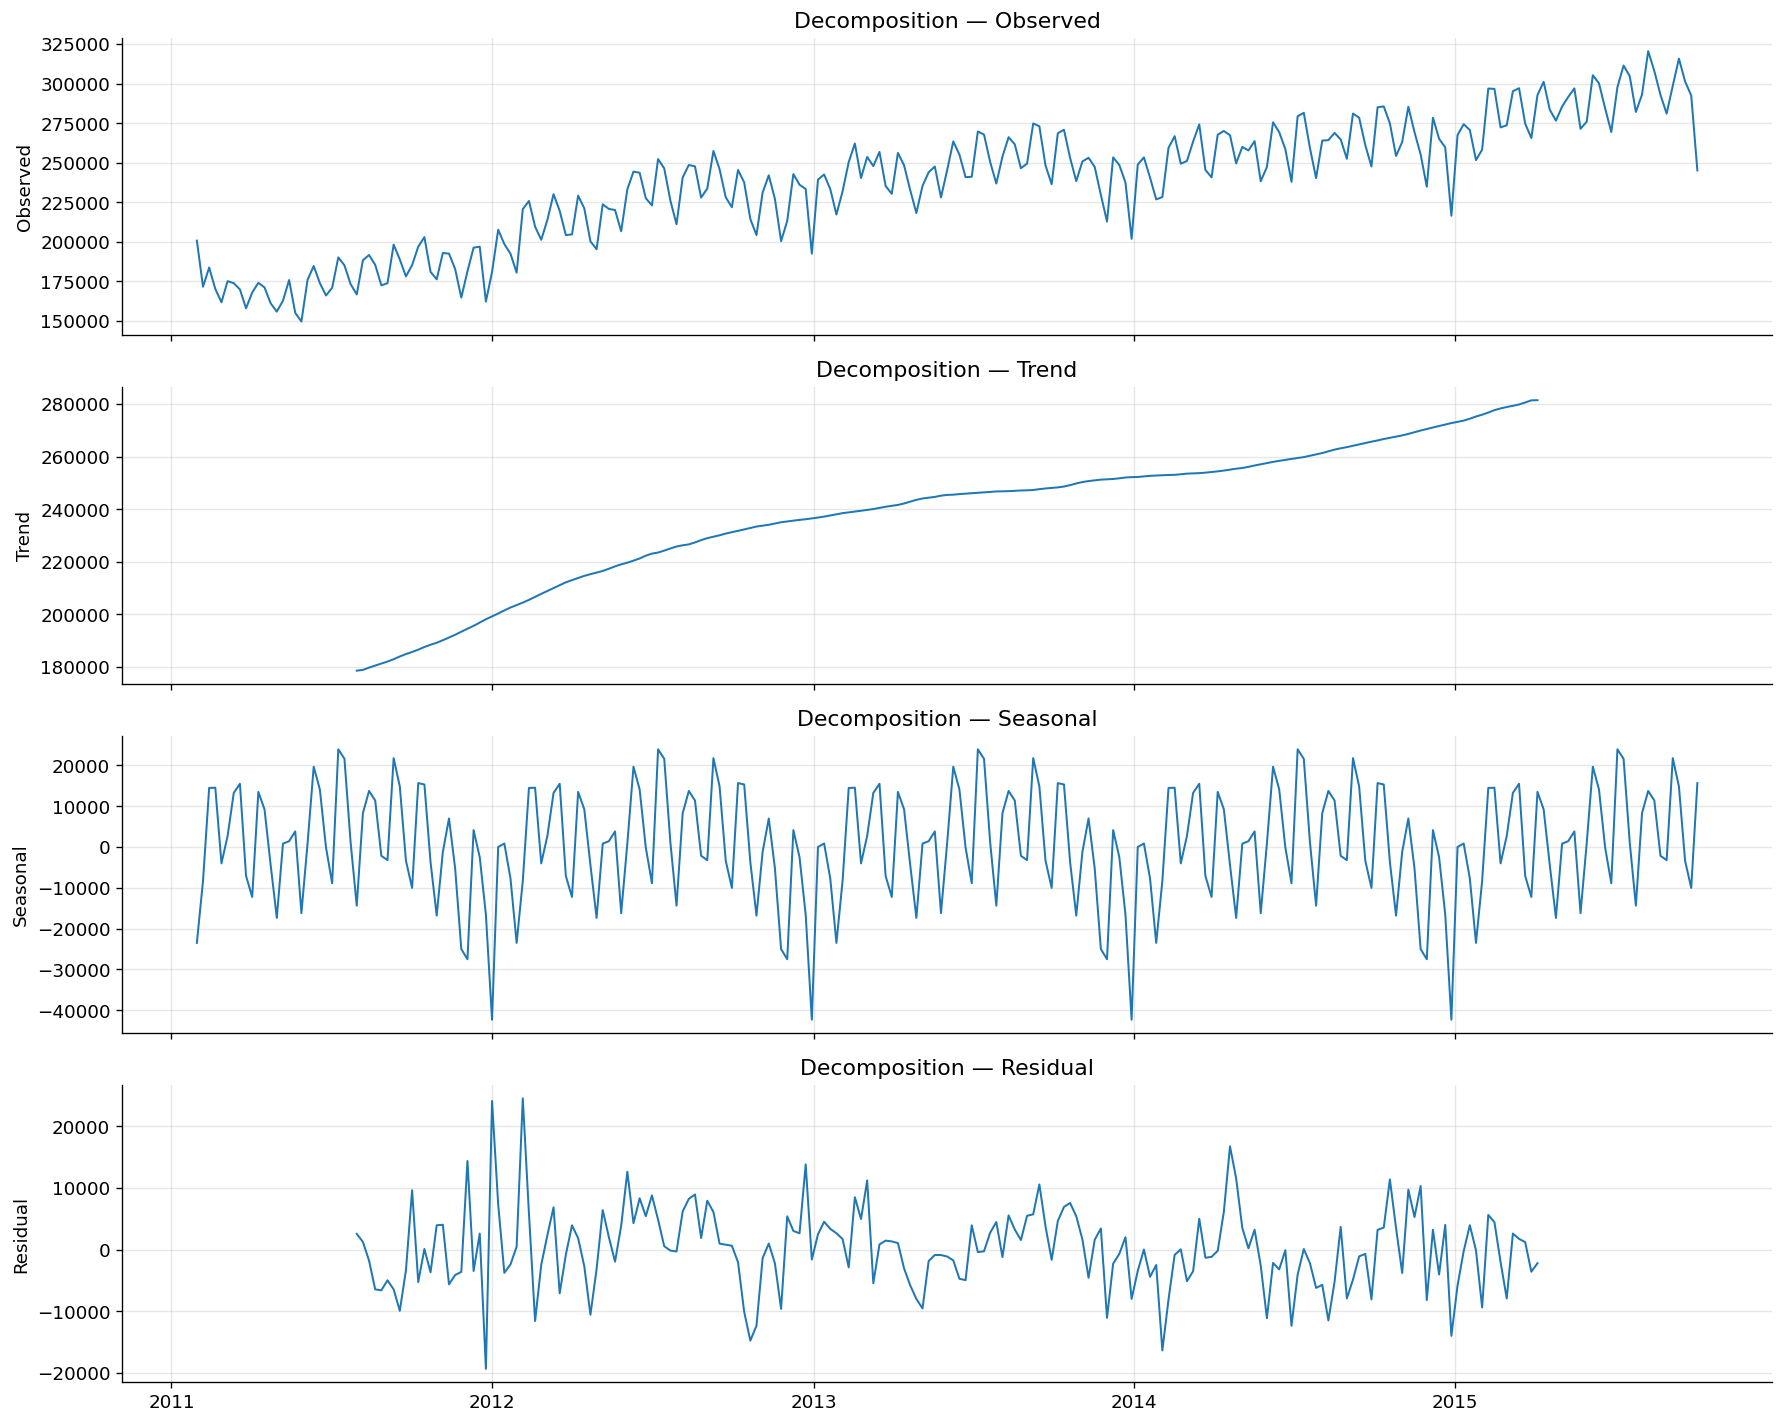

Variance decomposition (global weekly revenue):
  Trend    :   45.0%
  Seasonal :   12.3%
  Residual :    2.8%

► VERDICT: Global store-0 aggregate captures primarily trend — include as a global-level feature.


In [23]:
# Seasonal decomposition of global series
rev_weekly = global_df.set_index('date')['revenue'].resample('W').mean().ffill()

decomp = seasonal_decompose(rev_weekly, model='additive', period=52)

fig, axes = plt.subplots(4, 1, figsize=(15, 12), sharex=True)
for ax, component, label in zip(axes,
    [rev_weekly, decomp.trend, decomp.seasonal, decomp.resid],
    ['Observed','Trend','Seasonal','Residual']):
    ax.plot(rev_weekly.index, component, lw=1.2)
    ax.set_ylabel(label)
    ax.set_title(f'Decomposition — {label}')

plt.tight_layout()
plt.show()

trend_var    = decomp.trend.dropna().var()
seasonal_var = decomp.seasonal.var()
resid_var    = decomp.resid.dropna().var()
total_var    = rev_weekly.var()

print("Variance decomposition (global weekly revenue):")
print(f"  Trend    : {100*trend_var/total_var:>6.1f}%")
print(f"  Seasonal : {100*seasonal_var/total_var:>6.1f}%")
print(f"  Residual : {100*resid_var/total_var:>6.1f}%")
print()
print("► VERDICT: Global store-0 aggregate captures" +
      (" primarily trend" if trend_var > seasonal_var and trend_var > resid_var else
       " primarily seasonality" if seasonal_var > trend_var and seasonal_var > resid_var else
       " primarily noise") + " — include as a global-level feature.")

---
## 7. Noise vs Signal Estimation
### 7.1 Residual Variability

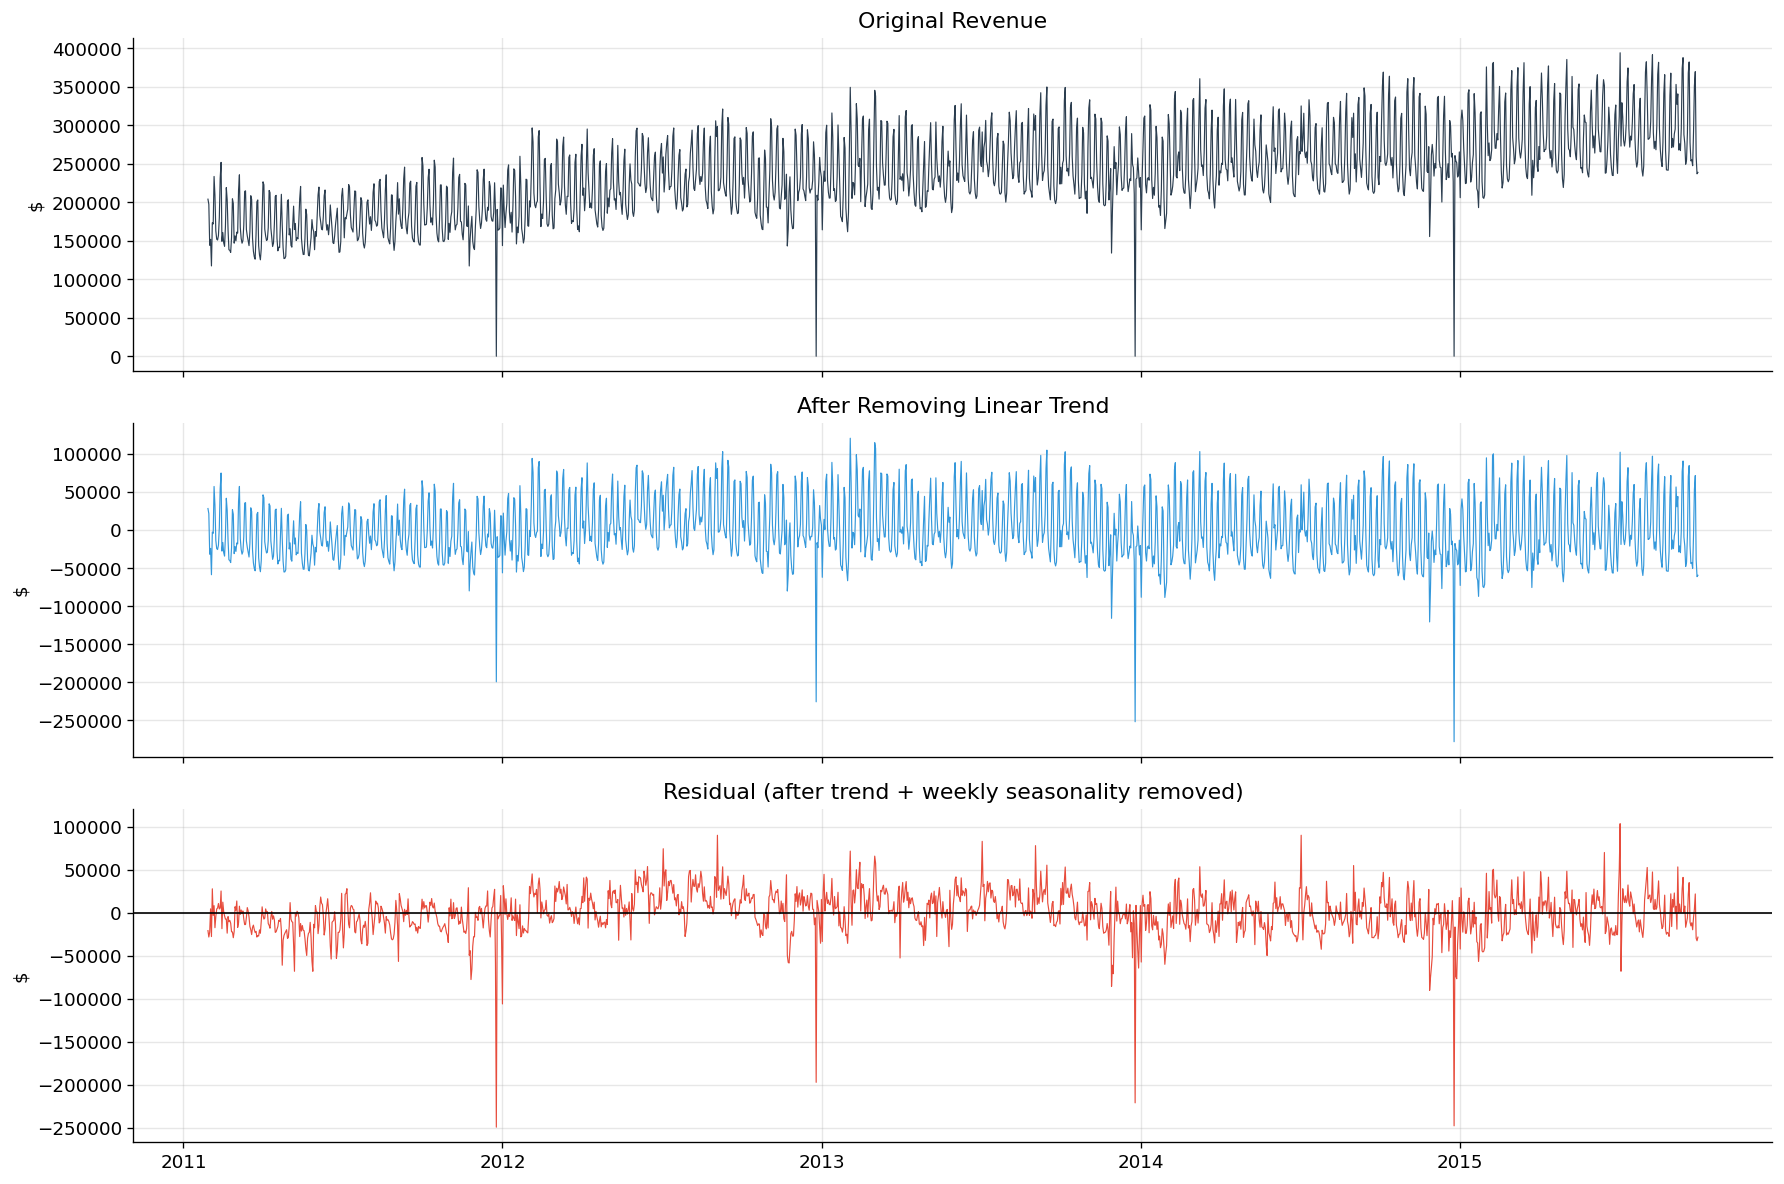

Original variance      :   2,984,825,807
Residual variance      :     631,951,252
Variance explained     :   78.8%
Residual std           : $    25,139
Residual / Mean ratio  : 0.1060

► Moderate signal remaining — event, monthly, and lag features will add predictive power.


In [24]:
# Remove trend and weekly seasonality from global series
g = global_df[['date','revenue','dow']].copy().set_index('date').sort_index()

# De-trend via OLS
x_n = np.arange(len(g))
sl, ic, _, _, _ = stats.linregress(x_n, g['revenue'].values)
g['detrended'] = g['revenue'] - (ic + sl * x_n)

# Remove weekly seasonality
dow_effect = g.groupby('dow')['detrended'].mean()
g['residual'] = g['detrended'] - g['dow'].map(dow_effect)

fig, axes = plt.subplots(3, 1, figsize=(15, 10), sharex=True)
axes[0].plot(g.index, g['revenue'],   color='#2c3e50', lw=0.7, label='Original')
axes[0].set_title('Original Revenue'); axes[0].set_ylabel('$')
axes[1].plot(g.index, g['detrended'], color='#3498db', lw=0.7, label='De-trended')
axes[1].set_title('After Removing Linear Trend'); axes[1].set_ylabel('$')
axes[2].plot(g.index, g['residual'],  color='#e74c3c', lw=0.7, label='Residual')
axes[2].axhline(0, color='black', lw=1)
axes[2].set_title('Residual (after trend + weekly seasonality removed)'); axes[2].set_ylabel('$')
plt.tight_layout()
plt.show()

orig_var = g['revenue'].var()
resid_var = g['residual'].var()
explained_pct = 100 * (1 - resid_var / orig_var)

print(f"Original variance      : {orig_var:>15,.0f}")
print(f"Residual variance      : {resid_var:>15,.0f}")
print(f"Variance explained     : {explained_pct:>6.1f}%")
print(f"Residual std           : ${g['residual'].std():>10,.0f}")
print(f"Residual / Mean ratio  : {g['residual'].std() / g['revenue'].mean():.4f}")
print()
if explained_pct > 80:
    print("► Trend + weekly seasonality explain most of the variance. Residual is relatively small.")
elif explained_pct > 50:
    print("► Moderate signal remaining — event, monthly, and lag features will add predictive power.")
else:
    print("► Substantial unexplained variance — complex modelling or richer features required.")

### 7.2 Outlier Analysis

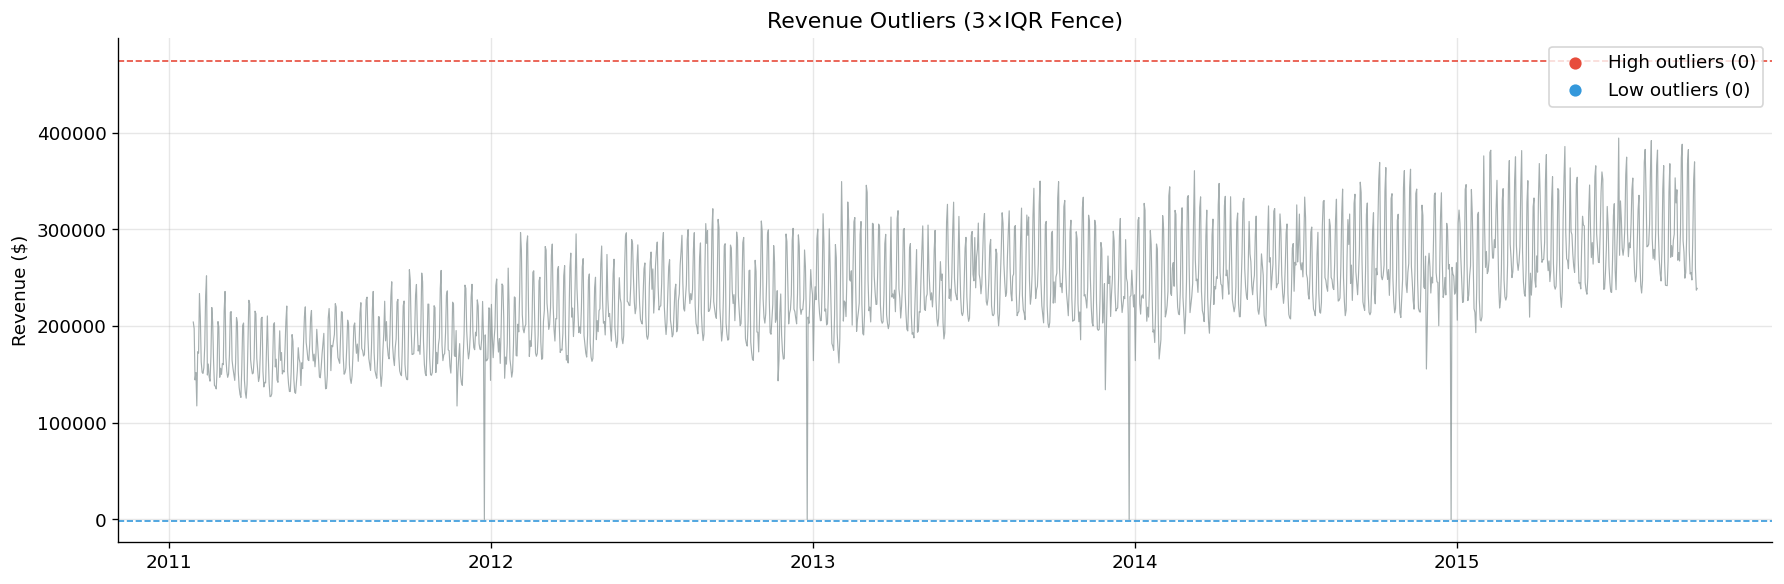

High-end outliers (> $474,503): 0
Low-end  outliers (< $-2,001): 0

Top outlier dates:

Outlier rate: 0.00% of observations
► VERDICT: Low outlier rate — standard loss functions are adequate.


In [25]:
# IQR-based outlier detection
q1, q3 = g['revenue'].quantile(0.25), g['revenue'].quantile(0.75)
iqr    = q3 - q1
lo_fence = q1 - 3 * iqr
hi_fence = q3 + 3 * iqr

outliers_high = g[g['revenue'] > hi_fence]
outliers_low  = g[g['revenue'] < lo_fence]

fig, ax = plt.subplots(figsize=(15, 5))
ax.plot(g.index, g['revenue'], color='#7f8c8d', lw=0.7, alpha=0.7)
ax.scatter(outliers_high.index, outliers_high['revenue'],
           color='#e74c3c', zorder=5, s=40, label=f'High outliers ({len(outliers_high)})')
ax.scatter(outliers_low.index, outliers_low['revenue'],
           color='#3498db', zorder=5, s=40, label=f'Low outliers ({len(outliers_low)})')
ax.axhline(hi_fence, color='#e74c3c', ls='--', lw=1)
ax.axhline(lo_fence, color='#3498db', ls='--', lw=1)
ax.set_title('Revenue Outliers (3×IQR Fence)')
ax.set_ylabel('Revenue ($)')
ax.legend()
plt.tight_layout()
plt.show()

# Annotate outliers with event labels
outlier_dates = pd.concat([outliers_high, outliers_low]).index
event_lookup  = events.set_index('date')['event']

print(f"High-end outliers (> ${hi_fence:,.0f}): {len(outliers_high)}")
print(f"Low-end  outliers (< ${lo_fence:,.0f}): {len(outliers_low)}")
print()
print("Top outlier dates:")
for d, rev in g.loc[outlier_dates, 'revenue'].sort_values(ascending=False).head(20).items():
    evt = event_lookup.get(d, 'no event')
    print(f"  {str(d.date()):>12}  ${rev:>12,.0f}  [{evt}]")

pct_outliers = 100 * (len(outliers_high) + len(outliers_low)) / len(g)
print(f"\nOutlier rate: {pct_outliers:.2f}% of observations")
print("► VERDICT: " +
      ("Low outlier rate — standard loss functions are adequate."
       if pct_outliers < 1
       else "Meaningful outlier presence — consider Huber loss, Tweedie, or revenue clipping."))

---
## 8. Final EDA Summary

In [26]:
# ── Compute summary metrics ────────────────────────────────────────────────────

# Trend strength (R² of OLS on weekly global)
wk_g = global_df.set_index('date')['revenue'].resample('W').mean()
_, _, r_trend, _, _ = stats.linregress(np.arange(len(wk_g)), wk_g.values)
trend_strength = 'Strong' if r_trend**2 > 0.3 else ('Medium' if r_trend**2 > 0.1 else 'Weak')

# Weekly seasonality
dow_g = global_df.groupby('dow')['revenue'].mean()
wkly_cv = dow_g.std() / dow_g.mean()
wkly_str = 'Strong' if wkly_cv > 0.1 else ('Medium' if wkly_cv > 0.05 else 'Weak')

# Monthly seasonality
mon_g = global_df.groupby('month')['revenue'].mean()
mon_ratio = mon_g.max() / mon_g.min()
mon_str = 'Strong' if mon_ratio > 1.15 else ('Medium' if mon_ratio > 1.05 else 'Weak')

# Quarterly
q_g = global_df.groupby('quarter')['revenue'].mean()
q_ratio = q_g.max() / q_g.min()
q_str = 'Strong' if q_ratio > 1.1 else ('Medium' if q_ratio > 1.03 else 'Weak')

# Yearly
yr_g = global_df.groupby('year')['revenue'].mean()
yr_cv = yr_g.std() / yr_g.mean()
yr_str = 'Strong' if yr_cv > 0.1 else ('Medium' if yr_cv > 0.03 else 'Weak')

# Event effects
evt_global_mean_abs = uplift_df['uplift_pct'].abs().mean()
evt_str = 'Strong' if evt_global_mean_abs > 10 else ('Medium' if evt_global_mean_abs > 3 else 'Weak')

# Lag structure
ci_val = 1.96 / np.sqrt(len(rev_clean))
lag_significant = sum(1 for l in [1,7,14,28] if abs(acf_vals[l]) > ci_val)
lag_str = 'Strong' if lag_significant >= 3 else ('Medium' if lag_significant >= 2 else 'Weak')

# Store hierarchy
store_cv_ratio = store_stats['mean'].max() / store_stats['mean'].min()
store_str = 'Strong' if store_cv_ratio > 2 else ('Medium' if store_cv_ratio > 1.3 else 'Weak')

# State effects
state_means = state_daily.mean()
state_ratio = state_means.max() / state_means.min()
state_str = 'Strong' if state_ratio > 1.5 else ('Medium' if state_ratio > 1.1 else 'Weak')

# Global effects (correlation)
global_str = 'Strong' if avg_global > 0.8 else ('Medium' if avg_global > 0.6 else 'Weak')

# Noise
noise_pct = 100 - explained_pct
noise_str = 'High' if noise_pct > 60 else ('Medium' if noise_pct > 30 else 'Low')

# ── Print table ────────────────────────────────────────────────────────────────
summary = [
    ('Trend',               trend_strength, f'OLS R²={r_trend**2:.3f} on weekly global'),
    ('Weekly Seasonality',  wkly_str,  f'DoW CV={wkly_cv:.3f}'),
    ('Monthly Seasonality', mon_str,   f'Max/Min ratio={mon_ratio:.3f}'),
    ('Quarterly Seasonality',q_str,    f'Max/Min ratio={q_ratio:.3f}'),
    ('Yearly Seasonality',  yr_str,    f'Year CV={yr_cv:.3f}'),
    ('Event Effects',       evt_str,   f'Avg |uplift|={evt_global_mean_abs:.1f}%'),
    ('Lag Structure',       lag_str,   f'{lag_significant}/4 key lags significant'),
    ('Store Hierarchy',     store_str, f'Mean rev ratio={store_cv_ratio:.2f}x'),
    ('State Effects',       state_str, f'State mean ratio={state_ratio:.2f}x'),
    ('Global Effects',      global_str,f'Avg store-global corr={avg_global:.3f}'),
    ('Noise Level',         noise_str, f'{noise_pct:.1f}% residual variance after trend+weekly removal'),
]

print(f"{'Signal Type':<25} {'Strength':<10} {'Notes'}")
print('─' * 80)
for sig, strength, notes in summary:
    print(f"{sig:<25} {strength:<10} {notes}")

print()
print('═' * 80)
print('FEATURE ENGINEERING RECOMMENDATIONS')
print('═' * 80)

recs = []
if trend_strength in ('Medium','Strong'):    recs.append('  ✓ Include time_index or year fractional features for trend.')
if wkly_str in ('Medium','Strong'):          recs.append('  ✓ Include day-of-week (one-hot or cyclic encoding).')
if mon_str in ('Medium','Strong'):           recs.append('  ✓ Include month (cyclic) and day-of-month features.')
if q_str  in ('Medium','Strong'):            recs.append('  ✓ Include quarter indicator.')
if evt_str in ('Medium','Strong'):           recs.append('  ✓ Include event indicator and event-type embeddings.')
if lag_significant >= 2:                     recs.append('  ✓ Include lag features at lags 1, 7, 14, 28.')
if store_str in ('Medium','Strong'):         recs.append('  ✓ Include store embedding or one-hot encoding.')
if state_str in ('Medium','Strong'):         recs.append('  ✓ Include state embedding.')
if global_str in ('Medium','Strong'):        recs.append('  ✓ Include global rolling mean as external regressor.')
if avg_interaction_std > 5:                  recs.append('  ✓ Include store × event interaction features.')
if noise_str in ('Medium','High'):           recs.append('  ⚠ Consider robust/quantile loss or log-transform of target.')

for r in recs:
    print(r)

Signal Type               Strength   Notes
────────────────────────────────────────────────────────────────────────────────
Trend                     Strong     OLS R²=0.808 on weekly global
Weekly Seasonality        Strong     DoW CV=0.151
Monthly Seasonality       Medium     Max/Min ratio=1.101
Quarterly Seasonality     Medium     Max/Min ratio=1.079
Yearly Seasonality        Strong     Year CV=0.174
Event Effects             Strong     Avg |uplift|=14.3%
Lag Structure             Strong     4/4 key lags significant
Store Hierarchy           Strong     Mean rev ratio=2.66x
State Effects             Strong     State mean ratio=1.73x
Global Effects            Strong     Avg store-global corr=0.860
Noise Level               Low        21.2% residual variance after trend+weekly removal

════════════════════════════════════════════════════════════════════════════════
FEATURE ENGINEERING RECOMMENDATIONS
════════════════════════════════════════════════════════════════════════════════
  ✓ In